# Part 2: Data Scientist Challenge (32 labels)

---

Part 2 explores various techniques to build an effective text classifier using only 32 labeled examples. It covers a fine-tuned BERT baseline (2a), dataset augmentation (2b), zero-shot LLM classification (2c), training on LLM-generated data (2d), and combining the best techniques via knowledge distillation (2e).

*Note: Heavy model training is executed on Colab. Shared utility functions are located in `src/models/`, and the detailed methodology can be found in `docs/PART2_PLAN.md`.*

## Table of Contents

* [Setup & Environment](#Setup-&-Environment)
* [2a. Baseline: BERT on 32 Examples](#2a.-Baseline:-BERT-on-32-Examples)
* [2b. Dataset Augmentation](#2b.-Dataset-Augmentation)
* [2c. Zero-shot LLM](#2c.-Zero-shot-LLM)
* [2d. LLM-generated data](#2d.-LLM-generated-data)
* [2e. Apply the most effective technique(s)](#2e.-Apply-the-most-effective-technique(s))
* [Bias Audit: Group-Mention Sensitivity](#Bias-Audit:-Group-Mention-Sensitivity)
* [Summary & Conclusion](#Summary-&-Conclusion)

## Setup & Environment

On Colab, install the pinned packages and mount Drive; torch is left as Colab ships it. Does nothing on a local run.

Shared helper functions live in `src/` (data, evaluation, plotting) and are documented in the project README.

In [1]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install -q datasets==4.8.5
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print('Local run detected - no Colab setup needed.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import hashlib
import json
import os
import random
import re
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

In [3]:
def _find_project_root(start):
    """Return the folder that contains data/processed. Walk up from `start` for local runs,
    then fall back to the Colab Drive locations (with or without the Final_submission folder)."""
    candidates = [start, *start.parents,
                  Path('/content/drive/MyDrive/BSE/NLP-PROJECT/Final_submission'),
                  Path('/content/drive/MyDrive/BSE/NLP-PROJECT')]
    for d in candidates:
        if (d / 'data' / 'processed').exists():
            return d
    raise FileNotFoundError(
        'Project root not found (no folder with data/processed). On Colab, mount Drive first '
        'and point this at the folder that holds src/, data/, and config/.')


PROJECT_ROOT = _find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT))
from src.utils.notebook_setup import bootstrap
from src.models.config import TrainConfig
from src.utils.evaluation import make_evaluate_model
from src.utils.guards import run_split_guard, run_train32_guard
from src.utils.metrics import evaluate_predictions, load_predictions
from src.utils.visualization import (
    plot_part2_augmentation_arms, plot_part2_llmgen_confusion_compare,
    plot_part2_synth_length_hist, plot_part2_bias_audit,

)

# config load, seeding, Colab/local switch, and the standard results paths come from
# bootstrap() (src/utils/notebook_setup.py). Per-part settings below still read config.yaml.
S = bootstrap(PROJECT_ROOT)
_CFG = S.cfg
SEED = S.SEED                                   # random + numpy already seeded inside bootstrap()
TRAIN_SEEDS = tuple(_CFG['train_seeds'])
CANONICAL_SEED = _CFG['canonical_seed']
IN_COLAB, RUN_TRAINING = S.IN_COLAB, S.RUN_TRAINING
DATA_DIR, RESULTS_DIR, METRICS_DIR, PRED_DIR, FIG_DIR, RAW_PRED_DIR = (
    S.DATA_DIR, S.RESULTS_DIR, S.METRICS_DIR, S.PRED_DIR, S.FIG_DIR, S.RAW_PRED_DIR)
CKPT_DIR = Path('/content/part2_ckpt') if IN_COLAB else Path(tempfile.gettempdir()) / 'part2_ckpt'

# Heavy GPU libraries load only on the training path, so local scoring runs stay light.
if RUN_TRAINING:
    import accelerate
    import torch
    import transformers
    from datasets import Dataset
    from transformers import (
        AutoModelForSequenceClassification, AutoTokenizer,
        DataCollatorWithPadding, Trainer, TrainingArguments, set_seed
    )

_bert = _CFG['bert']
MODEL_NAME = _bert['model_name']
MAX_LENGTH = _bert['max_length']
TRAIN_BATCH, EVAL_BATCH = _bert['train_batch'], _bert['eval_batch']
LR = _bert['lr']
EPOCHS = _bert['epochs']
WARMUP_STEPS = _bert['warmup_steps']
WEIGHT_DECAY = _bert['weight_decay']
LOGGING_STEPS = _bert['logging_steps']
MAX_FINAL_TRAIN_LOSS = _bert['max_final_train_loss']
DATASET_REVISION = _CFG['dataset']['revision']
VAL_SANITY_N = _CFG['eval']['val_sanity_n']
N_BOOT = _CFG['eval']['n_boot']

# Hyperparameters + run paths bundled for src.models.trainer.
cfg = TrainConfig(
    model_name=MODEL_NAME, max_length=MAX_LENGTH, train_batch=TRAIN_BATCH, eval_batch=EVAL_BATCH,
    lr=LR, epochs=EPOCHS, warmup_steps=WARMUP_STEPS, weight_decay=WEIGHT_DECAY,
    logging_steps=LOGGING_STEPS, max_final_train_loss=MAX_FINAL_TRAIN_LOSS,
    canonical_seed=CANONICAL_SEED, ckpt_dir=CKPT_DIR, raw_pred_dir=RAW_PRED_DIR,
)

_runs = _CFG['runs']
RUN_2A_NAME = _runs['run_2a']


def seed_run_name(seed):
    return f'{RUN_2A_NAME}_seed{seed}'


RUN_2B_BT_NAME = _runs['run_2b_bt']
RUN_2B_EDA_NAME = _runs['run_2b_eda']
REMOVED_AUG_IDS = tuple(_runs['removed_aug_ids'])

_zs = _CFG['zero_shot_2c']
RUN_2C_NAME = _runs['run_2c']
N_SUBSET_2C = _zs['n_subset']
MODEL_2C = _zs['model']
BATCH_2C = _zs['batch']
MAX_NEW_TOKENS_2C, MAX_NEW_TOKENS_COT = _zs['max_new_tokens_direct'], _zs['max_new_tokens_cot']
MAX_PROMPT_CANDIDATES = _zs['max_prompt_candidates']
PROMPT_DEV_VAL_CAP = _zs['prompt_dev_val_cap']

LLM_DIR = RESULTS_DIR / 'llm_runs'
LLM_DIR.mkdir(parents=True, exist_ok=True)
SUBSET_IDS_PATH = LLM_DIR / 'subsample_ids_n2100.json'
PROMPTDEV_IDS_PATH = LLM_DIR / 'promptdev_val_ids.json'
PROMPTDEV_CANDS_PATH = LLM_DIR / 'promptdev_candidates.json'
RUN_2C_JSONL = LLM_DIR / f'{RUN_2C_NAME}_responses.jsonl'
RUN_2C_META = LLM_DIR / f'{RUN_2C_NAME}_runmeta.json'

_synth = _CFG['synth_2d']
MODEL_2D_GEN = _synth['model_gen']
MODEL_2D_JUDGE = MODEL_2C
EMB_MODEL = _synth['emb_model']
N_SYNTH_PER_CLASS = _synth['n_synth_per_class']
N_RAW_PER_CLASS = _synth['n_raw_per_class']
TOPUP_EXTRA = _synth['topup_extra']
GEN_TEMPERATURE, GEN_TOP_P = _synth['gen_temperature'], _synth['gen_top_p']
GEN_MAX_NEW = _synth['gen_max_new']
GEN_BATCH = _synth['gen_batch']
GEN_PROMPT_VERSION = _synth['gen_prompt_version']
DEDUP_COSINE = _synth['dedup_cosine']

SYNTH_DIR = PROJECT_ROOT / 'data' / 'synthetic'
GEN_RAW_JSONL = LLM_DIR / 'part2d_gen_raw.jsonl'
SYNTH_PARQUET = SYNTH_DIR / 'synthetic.parquet'
SYNTH_MANIFEST = SYNTH_DIR / 'synthetic_manifest.json'
RUN_2D_NAMES = _runs['run_2d']


In [4]:
# Validate data splits and extract context (shared logic with local harness)
ctx = run_split_guard(DATA_DIR, expected_revision=DATASET_REVISION)
classes, test_df, y_test = ctx['classes'], ctx['test_df'], ctx['y_test']
labels, splits = ctx['labels'], ctx['splits']

# Validate the frozen 32-example draw against its manifest fingerprint.
# (Fails with FileNotFoundError until `python -m src.sampling` is run once)
train32 = run_train32_guard(DATA_DIR)


Split guard OK - test fingerprint 0da3f09e8a2b... matches the manifest.
Frozen splits: 64,069 train / 16,018 val / 20,022 test  -  dataset revision 186902250e94...
Train-32 guard OK - ids fingerprint 58a533fe6924... matches the manifest (32 examples).


On a first run the train-32 guard raises `FileNotFoundError` until `python -m src.data.sampling` is run once; after that the draw is frozen and never regenerated.

## 2a. Baseline: BERT on 32 Examples

Fine-tune `bert-base-uncased` on the 32 examples (recipe in `config/config.yaml`: lr 2e-5, 40 epochs, max length 256). We train three seeds (42, 43, 44) and report the mean and range, since results on 32 examples are seed-sensitive, and track suicidal recall (only four suicidal training examples, so it varies widely). A non-zero final train loss is expected (`docs/PART2_PLAN.md` section 4a).

### Data preparation

Tokenize the 20,022-row test set once in persisted order, and draw an unlabeled validation sanity sample to catch class collapse. Shared by every Part 2 experiment; test labels never enter training.

In [5]:
if RUN_TRAINING:
    label2id, id2label = labels['label2id'], labels['id2label']
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    def tokenize_frame(frame, with_labels=True):
        """Converts a DataFrame to a tokenized Hugging Face Dataset."""
        ds = Dataset.from_pandas(frame.reset_index(drop=True))

        def process_batch(batch):
            tokenized = tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)
            if with_labels:
                tokenized['labels'] = [label2id[s] for s in batch['status']]
            return tokenized

        return ds.map(
            process_batch,
            batched=True,
            remove_columns=[c for c in ('text', 'status') if c in ds.column_names]
        )

    test_ds = tokenize_frame(test_df, with_labels=False)

    val_sanity_df = splits['val'].sample(n=VAL_SANITY_N, random_state=SEED)
    val_sanity_ds = tokenize_frame(val_sanity_df, with_labels=False)


Map:   0%|          | 0/20022 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

### Shared trainer

Every arm trains through one function, `train_and_predict` (`src/models/trainer.py`), so accuracy differences come from the data, not the setup. It trains, predicts the test set, and writes raw predictions; scoring is separate and local.

In [6]:
def train_and_predict(train_df, run_name, seed, save_canonical=True):
    """Fine-tune cfg.model_name on train_df, then stage test predictions to results/colab_runs/.

    Thin adapter binding this notebook's runtime context (cfg + tokenized datasets) to
    src.models.trainer.train_and_predict; trainer is imported lazily so torch loads only
    on the Colab training path.

    Note: The underlying implementation will skip training if the output CSV already exists.
    """
    from src.models.trainer import train_and_predict as _impl
    return _impl(
        train_df, run_name, seed, cfg=cfg, classes=classes, id2label=id2label, label2id=label2id,
        tokenizer=tokenizer, tokenize_frame=tokenize_frame, test_ds=test_ds,
        val_sanity_ds=val_sanity_ds, test_df=test_df, save_canonical=save_canonical,
    )

### 2a driver

Train the three seeds (~10 min each on a T4); seeds already staged in `results/colab_runs/` are skipped. A local run only prints a notice.

In [7]:
# Run 3-seed training on the 32 examples. Skips existing runs.
if RUN_TRAINING:
    todo = [s for s in TRAIN_SEEDS if not (RAW_PRED_DIR / f'{seed_run_name(s)}.csv').exists()]
    summaries = [train_and_predict(train32, seed_run_name(seed), seed) for seed in todo]

    if summaries:
        print(pd.DataFrame(summaries).to_string(index=False))


### 2a scoring

Read the Colab predictions and score accuracy, macro F1, and suicidal recall across the three seeds, reporting the mean. The canonical seed (42) is fixed in advance; its metrics JSON and confusion matrix are persisted.

In [8]:
expected = {seed: RAW_PRED_DIR / f'{seed_run_name(seed)}.csv' for seed in TRAIN_SEEDS}
missing = [p.name for p in expected.values() if not p.exists()]

if missing:
    print(f'Missing CSVs: {missing}. Run training first.')
else:
    seed_preds, seed_rows, seed_runs = {}, [], {}
    for seed, path in expected.items():
        sidecar = path.with_suffix('.json')
        if sidecar.exists():
            run = json.loads(sidecar.read_text())
            seed_runs[str(seed)] = run
            if run['final_loss'] >= MAX_FINAL_TRAIN_LOSS:
                print(f"WARNING: seed {seed} final loss >= {MAX_FINAL_TRAIN_LOSS}.")
            if run['val_class_spread'] < len(classes):
                print(f"WARNING: seed {seed} possible class collapse.")

        preds = pd.read_csv(path, index_col='test_id')
        assert preds.index.equals(test_df.index), f'{path.name} not aligned with test index.'

        seed_preds[seed] = preds['y_pred'].to_numpy()
        m = evaluate_predictions(y_test, seed_preds[seed], classes)
        seed_rows.append({'seed': seed, 'accuracy': m['accuracy'],
                          'macro_f1': m['macro_f1'], 'kappa': m['kappa'],
                          'suicidal_recall': m['per_class']['suicidal']['recall']})

    seed_table = pd.DataFrame(seed_rows).set_index('seed')
    print(seed_table.round(4))
    print('\nMean/Std:')
    print(seed_table.agg(['mean', 'std']).round(4))

      accuracy  macro_f1   kappa  suicidal_recall
seed                                             
42      0.5768    0.5500  0.5023           0.1630
43      0.5539    0.5147  0.4746           0.1087
44      0.5678    0.5553  0.4963           0.4050

Mean/Std:
      accuracy  macro_f1   kappa  suicidal_recall
mean    0.5662    0.5400  0.4911           0.2256
std     0.0115    0.0221  0.0146           0.1577


### 2a results: baseline BERT (32 examples)

Main seed 42: accuracy 57.68% (3-seed mean 56.6%), macro F1 0.550, kappa 0.502. This beats random (14.5%) and majority (16.7%) but trails Part 1's rule-based 66.90% and mined lexicon 74.51%. Suicidal recall is highly unstable across the three seeds (16.3%, 10.9%, 40.5%), driven by only four suicidal training examples, which is why we report the range. Sanity checks pass: training loss fell to ~0.33 and the model predicted all seven classes (no class collapse).

## 2b. Dataset Augmentation

Enlarge the 32 examples with two augmentation methods and retrain BERT on each: back-translation (arm B, translate out and back) and EDA (arm C, random word edits). The arms share the 2a settings:

| Arm | Training data | Examples | Metrics file |
|---|---|---|---|
| A | 32 originals (2a baseline) | 32 | `part2_bert_32` |
| B | 32 originals + back-translation | ~160 | `part2_bert_backtrans` |
| C | 32 originals + EDA | ~160 | `part2_bert_eda_160` |

B and C see ~5x more data than A, so the fair test of augmentation is B against C. Generate once on Colab, hand-review the suicidal copies, score locally.

### Generation process

Generate arms B and C once on Colab and freeze them with a content fingerprint. Back-translation pivots each post through four languages; EDA swaps or drops words. The translation models are large (~2.4 GB), so this runs on Colab.

In [9]:
# 2b generation: runs ONCE on Colab, then data/augmented/ is frozen.
from src.data.augment import AUGMENTED, load_augmented, make_augmented_sets

AUG_MANIFEST = AUGMENTED / 'augmented_manifest.json'
assert AUGMENTED.resolve() == (DATA_DIR.parent / 'augmented').resolve(), \
    'src.augment.AUGMENTED resolves outside this project data folder'

if AUG_MANIFEST.exists():
    print('data/augmented/ is FROZEN (manifest exists) - generation skipped.')
elif not IN_COLAB:
    print('No augmented sets yet - run this cell ON COLAB to generate them (one time).')
else:
    import nltk
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    bt_aug, eda_aug, aug_manifest = make_augmented_sets(train32)
    print(json.dumps(aug_manifest['counts'], indent=2))

data/augmented/ is FROZEN (manifest exists) - generation skipped.


### Manual review of augmented data

We read every augmented copy of the four suicidal seeds and add any whose meaning shifted to `REMOVED_AUG_IDS`. Rewording can flip a suicidal post to harmless while keeping its label; the Part 1 lexicon flags candidates, but removals are decided by hand.

In [10]:
if not AUG_MANIFEST.exists():
    print('No augmented sets yet - run the generation cell on Colab, let Drive sync.')
else:
    aug_counts = json.loads(AUG_MANIFEST.read_text())['counts']
    print(json.dumps(aug_counts, indent=2))
    n_sui = sum(train32.loc[i, 'status'] == 'suicidal' for i in train32.index)
    print(f'{n_sui} suicidal seeds; their augmented copies are frozen per the manifest above.')


{
  "backtranslation": {
    "generated": 128,
    "dropped_identical": 6,
    "effective": 122,
    "effective_per_class": {
      "stress": 20,
      "depression": 20,
      "anxiety": 20,
      "personality disorder": 16,
      "bipolar": 16,
      "suicidal": 16,
      "normal": 14
    },
    "n_train_with_originals": 154
  },
  "eda": {
    "generated": 128,
    "dropped_identical": 3,
    "effective": 125,
    "effective_per_class": {
      "stress": 20,
      "depression": 20,
      "anxiety": 20,
      "normal": 17,
      "bipolar": 16,
      "personality disorder": 16,
      "suicidal": 16
    },
    "n_train_with_originals": 157
  }
}
4 suicidal seeds; their augmented copies are frozen per the manifest above.


### Augmented-data review result

Every augmented copy of the four suicidal posts kept its original meaning, so `REMOVED_AUG_IDS` stays empty and no copies are dropped before training.

Train arms B and C through the same `train_and_predict()` as 2a (only `train_df` changes), canonical seed, `save_canonical=False` (the staged CSVs are the deliverable, not the checkpoints). Already-staged arms are skipped.

In [11]:
arm_summaries = []
for run_name, method in ((RUN_2B_BT_NAME, 'backtranslation'), (RUN_2B_EDA_NAME, 'eda')):
    csv_path = RAW_PRED_DIR / f'{run_name}_seed{CANONICAL_SEED}.csv'
    if csv_path.exists():
        print(f'{run_name}: staged CSV already exists - skipping retrain.')
        continue
    aug_df = load_augmented(method)
    aug_df = aug_df[~aug_df['aug_id'].isin(REMOVED_AUG_IDS)]
    frame = pd.concat([train32[['text', 'status']],
                       aug_df[['text', 'status']]], ignore_index=True)
    print(f'{run_name}: {len(train32)} originals + {len(aug_df)} {method} = {len(frame)} train rows')
    arm_summaries.append(train_and_predict(frame, f'{run_name}_seed{CANONICAL_SEED}',
                                           CANONICAL_SEED, save_canonical=False))
if arm_summaries:
    print(pd.DataFrame(arm_summaries).to_string(index=False))


part2_bert_backtrans: staged CSV already exists - skipping retrain.
part2_bert_eda_160: staged CSV already exists - skipping retrain.


### 2b scoring (local)

Score arms B and C as in 2a: check the Colab sidecars, confirm alignment with the frozen test set, one `evaluate_model()` per arm, then the comparison figure. Exits cleanly while the Colab CSVs are missing.

Back-Translation scored.

EDA scored.



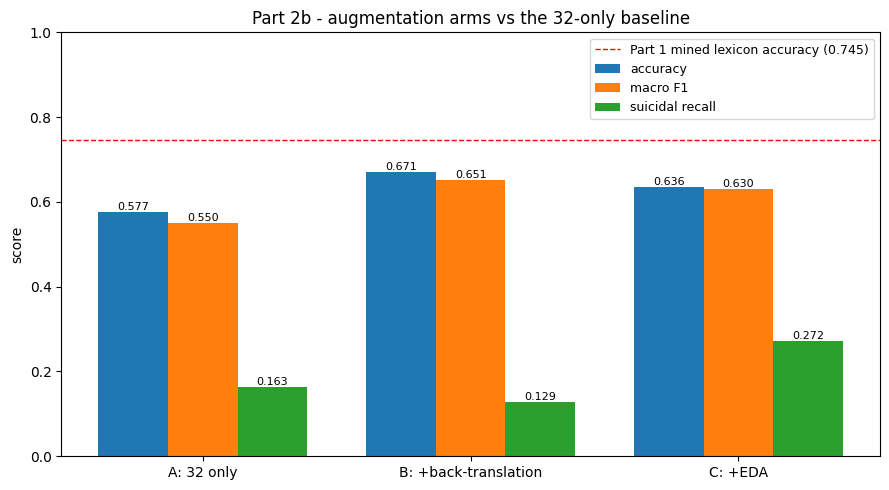

In [12]:
arm_specs = ((RUN_2B_BT_NAME, 'backtranslation'), (RUN_2B_EDA_NAME, 'eda'))
expected = {n: RAW_PRED_DIR / f'{n}_seed{CANONICAL_SEED}.csv' for n, _ in arm_specs}
missing = [p.name for p in expected.values() if not p.exists()]

if not AUG_MANIFEST.exists():
    print('Augmented sets not generated yet - run the 2b cycle first.')
elif missing:
    print('Raw prediction CSVs still missing:')
    for name in missing:
        print(f'  - {name}')
    print('Train arms B-C, then re-run this cell.')
else:
    aug_counts = json.loads(AUG_MANIFEST.read_text())['counts']
    for run_name, method in arm_specs:
        path = expected[run_name]
        sidecar = path.with_suffix('.json')
        run = json.loads(sidecar.read_text()) if sidecar.exists() else None
        if run is None:
            print(f'WARNING: {sidecar.name} missing - no sanity/version record for {run_name}.')
        else:
            if not run['final_loss'] < MAX_FINAL_TRAIN_LOSS:
                print(f"WARNING: {run_name} final train loss {run['final_loss']} >= {MAX_FINAL_TRAIN_LOSS}.")
            if run['val_class_spread'] < len(classes):
                print(f"WARNING: {run_name} possible class collapse.")
        preds = pd.read_csv(path, index_col='test_id')
        assert preds.index.equals(test_df.index), f'{path.name} is not aligned with test index.'
        prefix = 'bt_' if method == 'backtranslation' else 'eda_'
        removed = [a for a in REMOVED_AUG_IDS if a.startswith(prefix)]
        n_kept = aug_counts[method]['effective'] - len(removed)
        label = 'Back-Translation' if method == 'backtranslation' else 'EDA'
        print(f'{label} scored.\n')

    # Cross-arm figure: numbers come from the persisted metrics JSONs only.
    arms = [('A: 32 only', RUN_2A_NAME), ('B: +back-translation', RUN_2B_BT_NAME),
            ('C: +EDA', RUN_2B_EDA_NAME)]
    arm_metrics = [json.loads((METRICS_DIR / f'{name}.json').read_text()) for _, name in arms]
    plot_part2_augmentation_arms(arms, arm_metrics, metrics_dir=METRICS_DIR, fig_dir=FIG_DIR)

Back-translation (arm B) reaches **67.14% accuracy**. That is just above the rule-based floor of 66.90%, but below the mined lexicon at 74.51%. Its suicidal recall (the share of suicidal posts it catches) drops to **0.129**, below the mined lexicon's 0.453. EDA (arm C) reaches **63.63% accuracy** with suicidal recall **0.272**. So arm C has lower overall accuracy but catches more of the suicidal class, which is the metric we care about most. The fair comparison is B against C, because both train on a closely matched number of rows (154 for B, 157 for C, each being the 32 seeds plus their augmented copies) for the same 40 epochs. The jump from A up to B or C mixes the effect of augmentation with the extra training steps, so it is not a clean measure of augmentation alone.

## 2c. Zero-shot LLM

Label posts with `google/gemma-3-4b-it` (greedy decoding) and no training, on a fixed n=2,100 test sample that keeps the full test set's class balance, so accuracy stays comparable to the Part 1 bar. The prompt is built and tuned on validation only, in two answer formats (`direct` returns JSON, `cot` reasons first); only the validation winner touches the test set, once. Unreadable answers count as refusals (wrong, never dropped), and we report the refusal rate. Model cells run on Colab, scoring locally. Plan: section 4c.

We read the `HF_TOKEN` Colab secret to load the gated Gemma model (license accepted once on the model page). The token is never written here; local runs fall back to the env var or a saved `huggingface-cli login`.

In [13]:
# Set HF_TOKEN for gated models. On Colab, add a Secret named HF_TOKEN.
if 'HF_TOKEN' not in os.environ:
    try:
        from google.colab import userdata
        if token := userdata.get('HF_TOKEN'):
            os.environ['HF_TOKEN'] = token
    except Exception:
        print('Warning: HF_TOKEN not found in environment or Colab secrets.')

Draw the fixed 2,100-row sample with seed 42, save the IDs plus a fingerprint, and check on every re-run that nothing drifted. The sample keeps the full test set's class balance rather than equal counts per class.

In [14]:
from sklearn.model_selection import train_test_split

sub_idx, _ = train_test_split(test_df.index, train_size=N_SUBSET_2C,
                              stratify=test_df['status'], random_state=SEED)
sub_ids = sorted(int(i) for i in sub_idx)
sub_sha = hashlib.sha256(','.join(map(str, sub_ids)).encode()).hexdigest()

if SUBSET_IDS_PATH.exists():
    saved = json.loads(SUBSET_IDS_PATH.read_text())
    if saved['ids_sha256'] != sub_sha:
        raise ValueError('Recomputed n=2,100 subsample does not match the persisted one.')
    sub_ids = [int(i) for i in saved['ids']]
else:
    SUBSET_IDS_PATH.write_text(json.dumps(
        {'n': N_SUBSET_2C, 'seed': SEED, 'ids': sub_ids, 'ids_sha256': sub_sha,
         'source': 'test.parquet', 'dataset_revision': DATASET_REVISION}, indent=2))

sub_df = test_df.loc[sub_ids]


Define the prompt candidates (each label gets a one-line definition; the suicidal-versus-depression boundary is stated explicitly), lazy-load the model, and define the batch classifier. Candidates use the `direct` and `cot` formats; the next cell scores them on validation.

In [15]:
from src.models.llm import (
    BASE_TASK, DECISION_RULES, FORMAT_TAILS, LABEL_DEFINITIONS, MAX_INPUT_CHARS, _ids_sha256,
)
from src.models.llm import _parse_label as _llm_parse_label
from src.models.llm import make_candidate as _llm_make_candidate

assert set(LABEL_DEFINITIONS) == set(classes), 'LABEL_DEFINITIONS must match target classes'

FORMAT_MAX_NEW = {'direct': MAX_NEW_TOKENS_2C, 'cot': MAX_NEW_TOKENS_COT}


def make_candidate(name, body, fmt):
    """Build a 2c prompt candidate, supplying this notebook's per-format token budgets."""
    return _llm_make_candidate(name, body, fmt, FORMAT_MAX_NEW)


CANDIDATES = [
    make_candidate('v1_direct', BASE_TASK, 'direct'),
    make_candidate('v1_cot', BASE_TASK, 'cot'),
    make_candidate('v2_direct', BASE_TASK + DECISION_RULES, 'direct'),
    make_candidate('v2_cot', BASE_TASK + DECISION_RULES, 'cot')
]
assert len({c['name'] for c in CANDIDATES}) == len(CANDIDATES)
assert len(CANDIDATES) <= MAX_PROMPT_CANDIDATES


def _gpu_available():
    try:
        import torch
        return torch.cuda.is_available()
    except ImportError:
        return False


_model, _processor = None, None
def get_model():
    global _model, _processor
    if _model is None:
        import torch
        from transformers import AutoProcessor, Gemma3ForConditionalGeneration
        _processor = AutoProcessor.from_pretrained(MODEL_2C, padding_side='left')
        _model = Gemma3ForConditionalGeneration.from_pretrained(MODEL_2C, dtype=torch.bfloat16, device_map='cuda').eval()
    return _model, _processor

def get_judge():
    """The judge IS the 2c Gemma instance - one lazy load shared with the 2c cells."""
    return get_model()


def _parse_label(raw):
    """Parse the model's JSON label against this notebook's class set."""
    return _llm_parse_label(raw, classes)


def classify_batch(texts, cand):
    import torch
    model, proc = get_model()
    convs = [[{'role': 'system', 'content': [{'type': 'text', 'text': cand['system_prompt']}]},
              {'role': 'user', 'content': [{'type': 'text', 'text': t[:MAX_INPUT_CHARS]}]}]
             for t in texts]
    enc = proc.apply_chat_template(convs, add_generation_prompt=True, tokenize=True,
                                   return_dict=True, return_tensors='pt', padding=True).to(model.device)
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=cand['max_new_tokens'], do_sample=False)
    raws = proc.batch_decode(out[:, enc['input_ids'].shape[1]:], skip_special_tokens=True)
    return [{'label': _parse_label(r), 'refused': _parse_label(r) is None, 'raw': r.strip()} for r in raws]

def frozen_candidate():
    if not PROMPTDEV_CANDS_PATH.exists():
        return None
    scored = json.loads(PROMPTDEV_CANDS_PATH.read_text())['candidates']
    if len(scored) < 2:
        return None
    best = max(scored, key=lambda s: s['dev_accuracy'])
    cand = next((c for c in CANDIDATES if c['name'] == best['name']), None)
    if not cand or cand['hash'] != best['hash']:
        raise ValueError('Candidate definition mismatch.')
    return cand

FROZEN_CAND = frozen_candidate()
PROMPT_HASH = FROZEN_CAND['hash'] if FROZEN_CAND else None


In [16]:
# Prompt-fidelity self-check: these hashes pin the frozen prompts that generated/labeled
# the training data. If this cell raises, a frozen prompt string was edited - restore it
# from resources/copy_of_02_limited_data.py before scoring. (Local, no model needed.)
_EXPECTED_HASHES = {'v1_direct': 'de97c1f4eb7a', 'v1_cot': 'c8adf0d41731',
                    'v2_direct': '3a21817c83c1', 'v2_cot': 'cc45295b33bd'}
for _c in CANDIDATES:
    assert _c['hash'] == _EXPECTED_HASHES[_c['name']], (
        f"Prompt drift in {_c['name']}: {_c['hash']} != {_EXPECTED_HASHES[_c['name']]}. "
        'A frozen prompt string was changed - restore it before scoring.')
print('Prompt fidelity OK:', {c['name']: c['hash'] for c in CANDIDATES})

Prompt fidelity OK: {'v1_direct': 'de97c1f4eb7a', 'v1_cot': 'c8adf0d41731', 'v2_direct': '3a21817c83c1', 'v2_cot': 'cc45295b33bd'}


Score each unscored candidate on the same fixed validation rows, saving after each so the run resumes, and print a leaderboard and error report. Scoring stops once the locked test run starts, so the winner cannot change afterward. Needs the Colab GPU.

In [17]:
if not _gpu_available():
    print('No CUDA GPU. Run on Colab (A100).')
else:
    from sklearn.metrics import classification_report, precision_recall_fscore_support
    from tqdm.auto import tqdm

    val_df = splits['val']
    per_class = max(1, PROMPT_DEV_VAL_CAP // len(classes))
    dev_df = pd.concat([g.sample(min(len(g), per_class), random_state=SEED)
                        for _, g in val_df.groupby('status')]).head(PROMPT_DEV_VAL_CAP)

    dev_true = dev_df['status'].to_numpy()
    dev_texts = dev_df['text'].tolist()
    dev_sha = _ids_sha256(dev_df.index)

    book = json.loads(PROMPTDEV_CANDS_PATH.read_text()) if PROMPTDEV_CANDS_PATH.exists() else {
        'dev_ids_sha256': dev_sha, 'n_dev': len(dev_df), 'candidates': []
    }
    assert book['dev_ids_sha256'] == dev_sha, 'Validation subset drifted.'

    scored_names = {s['name'] for s in book['candidates']}
    todo = [c for c in CANDIDATES if c['name'] not in scored_names]

    if RUN_2C_JSONL.exists() and todo:
        print('Test run already started. Prompt dev is closed.')
        todo = []

    assert len(scored_names) + len(todo) <= MAX_PROMPT_CANDIDATES, 'Exceeded MAX_PROMPT_CANDIDATES.'

    sui_idx = list(classes).index('suicidal')

    for cand in todo:
        preds, n_ref = [], 0
        for start in tqdm(range(0, len(dev_texts), BATCH_2C), desc=cand['name'], unit='batch'):
            for r in classify_batch(dev_texts[start:start + BATCH_2C], cand):
                preds.append(r['label'] or '__refused__')
                n_ref += int(r['refused'])

        acc = float((np.array(preds) == dev_true).mean())
        _, rec, f1, _ = precision_recall_fscore_support(dev_true, preds, labels=list(classes), zero_division=0)

        book['candidates'].append({
            'name': cand['name'], 'format': cand['format'], 'hash': cand['hash'],
            'system_prompt': cand['system_prompt'], 'max_new_tokens': cand['max_new_tokens'],
            'dev_accuracy': acc, 'dev_macro_f1': float(np.mean(f1)),
            'dev_suicidal_recall': float(rec[sui_idx]), 'dev_refusals': n_ref,
            'dev_preds': preds
        })
        PROMPTDEV_CANDS_PATH.write_text(json.dumps(book, indent=2))
        print(f"{cand['name']}: acc {acc:.3f}, mF1 {float(np.mean(f1)):.3f}, sui_rec {float(rec[sui_idx]):.3f}, ref {n_ref}")

    if book['candidates']:
        board = sorted(book['candidates'], key=lambda s: -s['dev_accuracy'])
        print(f"\nLeaderboard (n={len(dev_df)}):")
        for s in board:
            print(f"  {s['dev_accuracy']:.3f} acc | {s['dev_macro_f1']:.3f} mF1 | "
                  f"sui-rec {s['dev_suicidal_recall']:.3f} | ref {s['dev_refusals']} | {s['name']}")

        best = board[0]
        print(f"\nWinner: {best['name']}")
        print(classification_report(dev_true, best['dev_preds'], labels=list(classes), zero_division=0))

        if len(book['candidates']) < MAX_PROMPT_CANDIDATES and not RUN_2C_JSONL.exists():
            wrong = [(t, p, txt) for t, p, txt in zip(dev_true, best['dev_preds'], dev_texts) if t != p]
            print(f"=== Error Report for {best['name']} ({len(wrong)} errors) ===")
            print(pd.Series([f'{t} -> {p}' for t, p, _ in wrong]).value_counts().head(10).to_string())
            for t, p, txt in wrong[:5]:
                print(f'- {t} -> {p} | {txt[:100]!r}')

    PROMPTDEV_IDS_PATH.write_text(json.dumps({
        'n': len(dev_df), 'ids': list(dev_df.index.astype(int)),
        'ids_sha256': dev_sha, 'n_candidates_scored': len(book['candidates'])
    }, indent=2))



Leaderboard (n=196):
  0.689 acc | 0.713 mF1 | sui-rec 0.643 | ref 6 | v2_direct
  0.663 acc | 0.664 mF1 | sui-rec 0.607 | ref 0 | v2_cot
  0.643 acc | 0.662 mF1 | sui-rec 0.429 | ref 7 | v1_direct
  0.622 acc | 0.630 mF1 | sui-rec 0.500 | ref 1 | v1_cot

Winner: v2_direct
                      precision    recall  f1-score   support

             anxiety       0.81      0.89      0.85        28
             bipolar       0.94      0.61      0.74        28
          depression       0.36      0.64      0.46        28
              normal       0.88      0.50      0.64        28
personality disorder       0.91      0.71      0.80        28
              stress       0.85      0.82      0.84        28
            suicidal       0.69      0.64      0.67        28

           micro avg       0.71      0.69      0.70       196
           macro avg       0.78      0.69      0.71       196
        weighted avg       0.78      0.69      0.71       196



On the validation rows the winner is **v2_direct** at **68.9%** accuracy. It beats v1_direct (64.3%), v2_cot (66.3%), and v1_cot (62.2%). The main mistake is over-predicting depression. Depression has the lowest precision (the share of depression guesses that are right) on the validation rows: 0.36, against recall of 0.64 (the share of real depression posts it catches). The v2 rules are written to fix this. Only this validation winner is locked for the single test run.

Classify all 2,100 sample rows once with the locked prompt, in resumable batches (appends to JSONL, skips done IDs). Unreadable answers are recorded as refusals. The only time the test sample is touched for this model.

In [18]:
if not _gpu_available():
    print('No CUDA GPU. Run on Colab (A100).')
else:
    from importlib.metadata import version
    from tqdm.auto import tqdm

    assert FROZEN_CAND is not None, 'No frozen candidate. Run prompt dev first.'

    done = set()
    if RUN_2C_JSONL.exists():
        with RUN_2C_JSONL.open() as f:
            done = {json.loads(line)['test_id'] for line in f if line.strip()}

    todo = [tid for tid in sub_ids if tid not in done]

    model, _ = get_model()
    RUN_2C_META.write_text(json.dumps({
        'model': MODEL_2C,
        'model_revision': getattr(model.config, '_commit_hash', None),
        'transformers_version': version('transformers'),
        'decoding': 'greedy',
        'candidate': FROZEN_CAND['name'],
        'format': FROZEN_CAND['format'],
        'max_new_tokens': FROZEN_CAND['max_new_tokens'],
        'batch_size': BATCH_2C,
        'prompt_hash': PROMPT_HASH
    }, indent=2))

    n_ok, n_ref = 0, 0
    with RUN_2C_JSONL.open('a') as f:
        bar = tqdm(range(0, len(todo), BATCH_2C), desc='test batches', unit='batch')
        for start in bar:
            batch_ids = todo[start:start + BATCH_2C]
            results = classify_batch(sub_df.loc[batch_ids, 'text'].tolist(), FROZEN_CAND)

            for tid, r in zip(batch_ids, results):
                f.write(json.dumps({'test_id': int(tid), 'prompt_hash': PROMPT_HASH, 'model': MODEL_2C, **r}) + '\n')
                n_ok += int(not r['refused'])
                n_ref += int(r['refused'])

            f.flush()
            bar.set_postfix(ok=n_ok, ref=n_ref, total=len(done) + n_ok + n_ref)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

test batches: 0batch [00:00, ?batch/s]

Score the run on the 7 classes (refusals count as wrong, never dropped), add a bootstrap 95% CI, save under the `_n2100` name, and run McNemar by hand against the Part 1 mined lexicon on the same IDs. A subset run, so it carries its own n and no predictions CSV (hence not `evaluate_model()`).

In [19]:
from sklearn.metrics import accuracy_score, cohen_kappa_score, precision_recall_fscore_support
from src.utils.metrics import load_predictions, mcnemar_test, save_metrics

if not RUN_2C_JSONL.exists():
    print('No responses yet - run the frozen-run cell first.')
else:
    with RUN_2C_JSONL.open() as f:
        resp = {d['test_id']: d for d in (json.loads(line) for line in f if line.strip())}

    stale = sum(r.get('prompt_hash') != PROMPT_HASH for r in resp.values()) if PROMPT_HASH else 0
    if stale:
        print(f'WARNING: {stale} rows carry a prompt hash other than the frozen {PROMPT_HASH} - investigate before scoring.')

    have = [tid for tid in sub_ids if tid in resp]
    if len(have) < len(sub_ids):
        print(f'Incomplete: {len(have)}/{len(sub_ids)} classified - finish the run first.')
    else:
        REFUSAL = '__refused__'
        y_true = sub_df.loc[sub_ids, 'status'].to_numpy()
        y_pred = np.array([resp[tid]['label'] if resp[tid]['label'] in classes else REFUSAL
                           for tid in sub_ids])
        n_refused = int((y_pred == REFUSAL).sum())

        prec, rec, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=list(classes), zero_division=0)
        per_class = {c: {'precision': float(p), 'recall': float(r), 'f1': float(fj), 'support': int(s)}
                     for c, p, r, fj, s in zip(classes, prec, rec, f1, support)}

        result = {
            'n': int(len(sub_ids)),
            'accuracy': float(accuracy_score(y_true, y_pred)),
            'macro_f1': float(np.mean(f1)),
            'weighted_f1': float(np.average(f1, weights=support)),
            'kappa': float(cohen_kappa_score(y_true, y_pred, labels=list(classes))),
            'per_class': per_class,
        }

        rng = np.random.default_rng(SEED)
        accs, f1s = np.empty(N_BOOT), np.empty(N_BOOT)
        for b in range(N_BOOT):
            idx = rng.integers(0, len(y_true), len(y_true))
            accs[b] = accuracy_score(y_true[idx], y_pred[idx])
            _, _, fb, _ = precision_recall_fscore_support(y_true[idx], y_pred[idx], labels=list(classes), zero_division=0)
            f1s[b] = float(np.mean(fb))

        pct = lambda a: [float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))]
        result.update({'accuracy_ci95': pct(accs), 'macro_f1_ci95': pct(f1s)})

        dev = json.loads(PROMPTDEV_IDS_PATH.read_text()) if PROMPTDEV_IDS_PATH.exists() else None
        run_meta = json.loads(RUN_2C_META.read_text()) if RUN_2C_META.exists() else None

        result.update({
            'model': MODEL_2C,
            'model_revision': run_meta.get('model_revision') if run_meta else None,
            'transformers_version': run_meta.get('transformers_version') if run_meta else None,
            'prompt_hash': PROMPT_HASH,
            'prompt_candidate': run_meta.get('candidate') if run_meta else None,
            'prompt_format': run_meta.get('format') if run_meta else None,
            'candidate_dev_scores': {s['name']: s['dev_accuracy'] for s in json.loads(PROMPTDEV_CANDS_PATH.read_text())['candidates']} if PROMPTDEV_CANDS_PATH.exists() else None,
            'decoding': 'greedy',
            'n_subset': int(len(sub_ids)),
            'subsample_ids_sha256': _ids_sha256(sub_ids),
            'n_refused': n_refused,
            'refusal_rate': float(n_refused / len(sub_ids)),
            'prompt_dev_val_n': dev['n'] if dev else None,
            'prompt_dev_val_ids_sha256': dev['ids_sha256'] if dev else None,
        })
        save_metrics(result, RUN_2C_NAME)

        print(f"{RUN_2C_NAME} Results:")
        print(f"Accuracy: {result['accuracy']:.4f} (95% CI: {result['accuracy_ci95'][0]:.4f}-{result['accuracy_ci95'][1]:.4f})")
        print(f"Macro F1: {result['macro_f1']:.4f}  |  Kappa: {result['kappa']:.4f}")
        print(f"Suicidal recall: {per_class['suicidal']['recall']:.4f}  |  Refusals: {n_refused}/{len(sub_ids)}")

        lex = load_predictions('part1_rule_based_mined').loc[sub_ids]
        mc = mcnemar_test(y_true, lex['y_pred'].to_numpy(), y_pred)
        print(f"McNemar vs mined lexicon (p-value): {mc['p_value']:.2e}")

part2_zero_shot_llm_n2100 Results:
Accuracy: 0.7233 (95% CI: 0.7057-0.7419)
Macro F1: 0.7350  |  Kappa: 0.7002
Suicidal recall: 0.6757  |  Refusals: 58/2100
McNemar vs mined lexicon (p-value): 6.45e-03


Zero-shot Gemma reaches **72.33% accuracy** (likely range 70.57 to 74.19). Its kappa (a score that corrects for lucky guessing) is **0.700**, and its macro-F1 (the average F1 across the 7 classes) is **0.735**. Suicidal recall, the share of real suicidal posts it catches, is **0.676**, above the 0.453 mined-lexicon bar. This matters because that recall is the ethics-critical metric. There were **58 refusals** out of 2,100 (**2.76%**), all counted wrong. Overall accuracy sits just below the mined lexicon's 74.51%, but the jump in suicidal recall is the result worth carrying forward.

## 2d. LLM-generated data

`Llama-3.2-3B-Instruct` writes new labeled posts (sampled decoding); `gemma-3-4b-it` judges them in QC with its frozen 2c prompt. Writer and judge differ, so no model grades its own work. (The plan had the roles reversed, but Llama failed the judge-calibration check, so we swapped them.) Synthetic suicidal text is held to a firm safety boundary: distress and passive ideation only, no methods or plans. We retrain BERT on the synthetic posts plus the 32 real ones:

| Arm | Training data | Metrics JSON | Isolates |
|---|---|---|---|
| A | 32 only (= 2a) | `part2_bert_32.json` | baseline |
| B | 32 + 50/class | `part2_bert_llmgen_50.json` | scale (low) |
| C | 32 + 200/class (headline) | `part2_bert_llmgen_200.json` | headline effect |
| D | synthetic-only 200/class | `part2_bert_synth_only.json` | value of the 32 real anchors |

LLM labels are weak labels; we expect a clear win over the 32-only baseline but not a match for real data, and the size of the remaining gap is the finding. Plan: section 4d. Anchors: Schick and Schutze 2021 (DINO); arXiv:2310.07849, 2306.15895.

Build the generation helpers. Few-shot prompts are seeded only from the 32 training posts; AttrPrompt-style slots (persona, trigger, length, register) avoid template repetition; the system prompt enforces the suicidal safety boundary (distress and passive ideation only).

In [20]:
from src.models.llm import CLASS_MARKERS, DISTRESS_TRIGGERS, NORMAL_TRIGGERS, parse_post
from src.models.llm import build_gen_messages as _llm_build_gen_messages

CLASS_SEEDS = {c: g['text'].tolist() for c, g in train32.groupby('status')}
CLASS_LIST = sorted(CLASS_SEEDS)
CLASS_TRIGGERS = {c: (NORMAL_TRIGGERS if c == 'normal' else DISTRESS_TRIGGERS) for c in CLASS_LIST}

assert set(CLASS_MARKERS) == set(CLASS_LIST)


def build_gen_messages(cls, idx):
    """Prompt for synthetic post #idx of class cls, binding this notebook's seed and class data."""
    return _llm_build_gen_messages(cls, idx, SEED, CLASS_LIST, CLASS_SEEDS, CLASS_TRIGGERS)


_llama_model, _llama_tok = None, None

def get_llama():
    """Lazy loads the LLM to preserve GPU memory until required."""
    global _llama_model, _llama_tok
    if _llama_model is None:
        import torch
        from transformers import AutoModelForCausalLM, AutoTokenizer
        _llama_tok = AutoTokenizer.from_pretrained(MODEL_2D_GEN, padding_side='left')
        if not _llama_tok.pad_token:
            _llama_tok.pad_token = _llama_tok.eos_token
        _llama_model = AutoModelForCausalLM.from_pretrained(
            MODEL_2D_GEN, dtype=torch.bfloat16, device_map='cuda').eval()
    return _llama_model, _llama_tok

def generate_posts(convs, first_idx):
    """Generates a batch of posts using sampled decoding."""
    import torch
    model, tok = get_llama()
    torch.manual_seed(SEED * 1_000_003 + first_idx)

    enc = tok.apply_chat_template(convs, add_generation_prompt=True, tokenize=True,
                                  return_dict=True, return_tensors='pt', padding=True).to(model.device)
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=GEN_MAX_NEW, do_sample=True,
                             temperature=GEN_TEMPERATURE, top_p=GEN_TOP_P, pad_token_id=tok.pad_token_id)
    return tok.batch_decode(out[:, enc['input_ids'].shape[1]:], skip_special_tokens=True)

def load_synthetic():
    """Loads the synthetic dataset and validates its integrity fingerprint."""
    assert SYNTH_MANIFEST.exists(), 'no frozen synthetic set yet - run the 2d generation + QC cells on Colab'
    manifest = json.loads(SYNTH_MANIFEST.read_text())
    df = pd.read_parquet(SYNTH_PARQUET)
    fp = hashlib.sha256('\n'.join(f"{r.gen_id}|{r.status}|{r.text}" for r in df.itertuples()).encode()).hexdigest()
    assert fp == manifest['content_sha256'], "Dataset fingerprint mismatch: data/synthetic has been modified."
    return df


The judge is the 2c Gemma model reading `FROZEN_CAND`, so it cannot drift from what 2c froze, and it is a different model from the Llama writer. Gemma relabels each candidate in a fresh greedy call; a per-post confidence is recorded for analysis only, never as a filter.

In [21]:
assert FROZEN_CAND is not None, 'Run 2c prompt development first to freeze a candidate.'

JUDGE_SYSTEM = (
    FROZEN_CAND['system_prompt'] if FROZEN_CAND['format'] == 'direct'
    else FROZEN_CAND['system_prompt'].replace(FORMAT_TAILS['cot'], FORMAT_TAILS['direct'])
)

def judge_batch(texts):
    """Runs a greedy classification batch and returns labels with confidence scores."""
    import torch
    import torch.nn.functional as F

    model, proc = get_model()
    convs = [
        [{'role': 'system', 'content': [{'type': 'text', 'text': JUDGE_SYSTEM}]},
         {'role': 'user', 'content': [{'type': 'text', 'text': t[:MAX_INPUT_CHARS]}]}]
        for t in texts
    ]

    enc = proc.apply_chat_template(convs, add_generation_prompt=True, tokenize=True,
                                   return_dict=True, return_tensors='pt', padding=True).to(model.device)

    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=MAX_NEW_TOKENS_2C, do_sample=False,
                             return_dict_in_generate=True, output_scores=True)

    seq = out.sequences[:, enc['input_ids'].shape[1]:]
    raws = proc.batch_decode(seq, skip_special_tokens=True)

    pad_id = proc.tokenizer.pad_token_id
    logp = torch.zeros(seq.shape, dtype=torch.float32, device=seq.device)

    for t, step_scores in enumerate(out.scores):
        logp[:, t] = F.log_softmax(step_scores.float(), dim=-1).gather(-1, seq[:, t:t+1]).squeeze(-1)

    mask = (seq != pad_id).float()
    conf = (logp * mask).sum(1) / mask.sum(1).clamp(min=1)

    return [{'label': _parse_label(r), 'conf': float(c)} for r, c in zip(raws, conf.exp().tolist())]


Before judging synthetic posts, the judge must label the 32 real seeds and recover every class on at least 50% of them. The first run used Llama and failed (20 of 32, suicidal 0 of 4), which triggered the role swap; the judge tested here is Gemma with its frozen 2c prompt. Uses only the 32 posts, so nothing leaks. If this also fails there is no third model, so we stop and decide jointly.

In [22]:
# 2d-2b judge calibration gate (plan 4d amendment 2026-06-12). Read-only: writes no artifacts, uses only the 32.
if not _gpu_available():
    print('No CUDA GPU - run this cell on Colab (A100). Skipping.')
else:
    cal = train32[['text', 'status']].copy()
    _judged = judge_batch(cal['text'].tolist())
    cal['judge_label'] = [j['label'] for j in _judged]
    cal['ok'] = cal['judge_label'] == cal['status']
    per = cal.groupby('status')['ok'].agg(correct='sum', n='count')
    print(f"Judge calibration on the 32 real seeds: {int(cal['ok'].sum())}/32 correct overall.")
    print(per.to_string())
    _fails = per[per['correct'] < 0.5 * per['n']].index.tolist()
    if _fails:
        print(f'\nGATE FIRED: judge recovered <50% of {_fails} on REAL posts.')
        print('Roles were ALREADY swapped on 2026-06-12 (Llama failed this gate 20/32;')
        print('Gemma is now the judge). There is NO third model - STOP and decide with')
        print('Anabel (options in the session-doc addendum) before regenerating.')
    else:
        print('\nGate PASSED: judge keeps the QC role. Proceed to (re)generation.')


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Deprecated: `processor.image_token` will switch from returning `tokenizer.image_token` to `tokenizer.boi_token` in v5.11.


Judge calibration on the 32 real seeds: 24/32 correct overall.
                      correct  n
status                          
anxiety                     4  5
bipolar                     3  4
depression                  3  5
normal                      3  5
personality disorder        3  4
stress                      5  5
suicidal                    3  4

Gate PASSED: judge keeps the QC role. Proceed to (re)generation.


The check passed after the swap. Gemma labels 24 of the 32 real seed posts correctly and clears the 50% floor in every class. The two lowest are depression and normal, each at three of five. So the judge keeps its quality-control role.

The generation driver runs on Colab and resumes if interrupted, writing each raw post immediately and topping up only classes below target (`N_RAW_PER_CLASS` plus `TOPUP_EXTRA`). Skipped once `data/synthetic/` is frozen.

In [23]:
if SYNTH_MANIFEST.exists():
    print('data/synthetic/ is FROZEN (manifest exists) - generation skipped.')
elif not _gpu_available():
    print('No CUDA GPU - run this cell on Colab (A100). Skipping.')
else:
    from tqdm.auto import tqdm

    rows = []
    if GEN_RAW_JSONL.exists():
        with GEN_RAW_JSONL.open() as f:
            rows = [json.loads(l) for l in f if l.strip()]
    parsed = {c: sorted(r['idx'] for r in rows if r['cls'] == c and r['text']) for c in CLASS_LIST}
    next_idx = {c: max((r['idx'] for r in rows if r['cls'] == c), default=-1) + 1 for c in CLASS_LIST}
    quota = {c: N_RAW_PER_CLASS + TOPUP_EXTRA.get(c, 0) for c in CLASS_LIST}
    need = {c: max(0, quota[c] - len(parsed[c])) for c in CLASS_LIST}
    print('Parsed so far:', {c: len(parsed[c]) for c in CLASS_LIST})
    print('Still needed :', need)

    n_fail = 0
    with GEN_RAW_JSONL.open('a') as f:
        for cls in CLASS_LIST:
            if need[cls] == 0:
                continue
            bar = tqdm(total=need[cls], desc=f'gen {cls}', unit='post')
            while need[cls] > 0:
                idxs = list(range(next_idx[cls], next_idx[cls] + min(GEN_BATCH, need[cls] + 4)))
                built = [build_gen_messages(cls, i) for i in idxs]
                raws = generate_posts([b[0] for b in built], idxs[0])
                for i, (conv_attrs, raw) in zip(idxs, zip([b[1] for b in built], raws)):
                    text = parse_post(raw)
                    f.write(json.dumps({'gen_id': f'{cls.replace(" ", "_")}_{i:04d}', 'cls': cls,
                                        'idx': i, 'attrs': conv_attrs, 'text': text,
                                        'raw': None if text else raw[:500]}) + '\n')
                    if text:
                        if need[cls] > 0:
                            bar.update(1)
                        need[cls] = max(0, need[cls] - 1)
                    else:
                        n_fail += 1
                f.flush()
                next_idx[cls] = idxs[-1] + 1
            bar.close()
    print(f'Done: all classes at raw quota ({quota}); {n_fail} parse failures this session '
          f'(regenerated, never kept). Next: the QC cell.')


data/synthetic/ is FROZEN (manifest exists) - generation skipped.


Three QC stages, then freeze. Stage 1: near-duplicate removal by cosine similarity at or above `DEDUP_COSINE`, also against the 32 seeds. Stage 2: judge relabel (agree keeps, disagree drops, no-judgment keeps but flags). Stage 3: report-only length and leakage check. A shortfall saves nothing; on success `data/synthetic/` is written once and fingerprint-guarded.

In [24]:
# 2d-4 QC pipeline + freeze (plan 4d). MiniLM runs through the pinned transformers stack (mean pooling, model-card recipe); no sentence-transformers dependency.
if SYNTH_MANIFEST.exists():
    print('data/synthetic/ is FROZEN (manifest exists) - QC already done.')
    print(json.dumps(json.loads(SYNTH_MANIFEST.read_text())['counts'], indent=2))
elif not _gpu_available():
    print('No CUDA GPU - run this cell on Colab (A100). Skipping.')
elif not GEN_RAW_JSONL.exists():
    print('No raw generations yet - run the generation driver above first.')
else:
    import torch
    from tqdm.auto import tqdm
    from transformers import AutoModel, AutoTokenizer

    with GEN_RAW_JSONL.open() as f:
        raw_rows = [json.loads(l) for l in f if l.strip()]
    cand = (pd.DataFrame([r for r in raw_rows if r['text']])
              .sort_values(['cls', 'idx']).reset_index(drop=True))
    n_parse_fail = sum(1 for r in raw_rows if not r['text'])
    print(f'{len(cand)} parsed candidates ({n_parse_fail} parse failures discarded at source).')

    # --- stage 1: embedding dedup ---
    emb_tok = AutoTokenizer.from_pretrained(EMB_MODEL)
    emb_model = AutoModel.from_pretrained(EMB_MODEL).to('cuda').eval()
    def embed(texts):
        out = []
        for s in tqdm(range(0, len(texts), 256), desc='embed', unit='batch'):
            enc = emb_tok(texts[s:s + 256], padding=True, truncation=True,
                          max_length=256, return_tensors='pt').to('cuda')
            with torch.no_grad():
                h = emb_model(**enc).last_hidden_state
            mask = enc['attention_mask'].unsqueeze(-1)
            v = (h * mask).sum(1) / mask.sum(1)            # mean pooling (model-card recipe)
            out.append(torch.nn.functional.normalize(v, dim=1).cpu())
        return torch.cat(out).numpy()

    seed_texts = train32['text'].tolist()
    E = embed(cand['text'].tolist() + seed_texts)
    cand_E, seed_E = E[:len(cand)], E[len(cand):]
    keep_mask, kept_vecs = [], [seed_E]                    # seeds are "already kept"
    for v in cand_E:                                       # generation order = keep-first
        sims = np.concatenate(kept_vecs) @ v
        ok = bool(sims.max() < DEDUP_COSINE)
        keep_mask.append(ok)
        if ok:
            kept_vecs.append(v[None, :])
    cand['dedup_kept'] = keep_mask
    dedup = cand[cand['dedup_kept']].reset_index(drop=True)
    print(f'Stage 1 dedup: kept {len(dedup)}/{len(cand)} (cosine < {DEDUP_COSINE}, incl. vs the 32 seeds).')

    # --- stage 2: judge relabel (different model) ---
    judged = []
    for s in tqdm(range(0, len(dedup), BATCH_2C), desc='judge', unit='batch'):
        judged.extend(judge_batch(dedup['text'].iloc[s:s + BATCH_2C].tolist()))
    dedup['judge_label'] = [j['label'] for j in judged]
    dedup['judge_conf'] = [j['conf'] for j in judged]   # record-only - never a filter (plan 4d)
    dedup['outcome'] = np.where(dedup['judge_label'] == dedup['cls'], 'agree',
                        np.where(dedup['judge_label'].isna(), 'flagged', 'disagree'))
    accepted = dedup[dedup['outcome'] != 'disagree'].reset_index(drop=True)
    print('Stage 2 judge outcomes:')
    print(dedup.groupby(['cls', 'outcome']).size().unstack(fill_value=0).to_string())

    # --- stage 3: distribution report (report-only, plan 4d) ---
    real_words = splits['train']['text'].str.split().str.len()   # text-only use of train: in-bounds
    synth_words = accepted['text'].str.split().str.len()
    print(f'\nStage 3 - words/post: real train median {real_words.median():.0f} '
          f'(p90 {real_words.quantile(.9):.0f}), synthetic median {synth_words.median():.0f} '
          f'(p90 {synth_words.quantile(.9):.0f})')
    print('Label-leakage check (share of posts containing their own class name):')
    for c in CLASS_LIST:
        leak_s = accepted.loc[accepted['cls'] == c, 'text'].str.contains(c, case=False).mean()
        leak_r = train32.loc[train32['status'] == c, 'text'].str.contains(c, case=False).mean()
        flag = '  <-- WARNING: way above real - check for the label-in-text shortcut' \
               if (leak_s > 0.3 and leak_s > 2 * max(leak_r, 0.05)) else ''
        print(f'  {c:22s} synth {leak_s:.2f} vs the-32 {leak_r:.2f}{flag}')

    # --- balance check, then freeze ---
    per_class = accepted.groupby('cls').size().to_dict()
    short = {c: N_SYNTH_PER_CLASS - per_class.get(c, 0) for c in CLASS_LIST
             if per_class.get(c, 0) < N_SYNTH_PER_CLASS}
    if short:
        print(f'\nSHORTFALL after QC: {short}. NOT persisting. Set TOPUP_EXTRA in the config '
              f'cell to about 1.5x the shortfall (e.g. {{c: int(n * 1.5) for c, n in ...}}), '
              're-run the generation driver, then re-run this cell.')
    else:
        final = (accepted.groupby('cls', group_keys=False).head(N_SYNTH_PER_CLASS)
                 .rename(columns={'cls': 'status'})
                 [['gen_id', 'text', 'status', 'outcome', 'judge_conf']].reset_index(drop=True))
        SYNTH_DIR.mkdir(parents=True, exist_ok=True)
        final.to_parquet(SYNTH_PARQUET, index=False)
        fp = hashlib.sha256('\n'.join(f"{r.gen_id}|{r.status}|{r.text}"
                                      for r in final.itertuples()).encode()).hexdigest()
        gen_commit = getattr(get_llama()[0].config, '_commit_hash', None)
        judge_commit = getattr(get_judge()[0].config, '_commit_hash', None)
        counts = {c: {'raw_parsed': int((cand['cls'] == c).sum()),
                      'dedup_dropped': int(((cand['cls'] == c) & ~cand['dedup_kept']).sum()),
                      'judge_disagree': int(((dedup['cls'] == c) & (dedup['outcome'] == 'disagree')).sum()),
                      'judge_flagged': int(((dedup['cls'] == c) & (dedup['outcome'] == 'flagged')).sum()),
                      'accepted': int(per_class[c]), 'kept': int((final['status'] == c).sum())}
                  for c in CLASS_LIST}
        SYNTH_MANIFEST.write_text(json.dumps({
            'content_sha256': fp, 'n': int(len(final)), 'n_per_class_target': N_SYNTH_PER_CLASS,
            'generator': {'model': MODEL_2D_GEN, 'revision': gen_commit, 'decoding': 'sampled',
                          'temperature': GEN_TEMPERATURE, 'top_p': GEN_TOP_P,
                          'max_new_tokens': GEN_MAX_NEW, 'seed_scheme': 'torch.manual_seed(SEED*1000003+first_idx) per batch',
                          'gen_prompt_version': GEN_PROMPT_VERSION},
            'judge': {'model': MODEL_2D_JUDGE, 'revision': judge_commit, 'decoding': 'greedy',
                      'prompt': f"2c frozen candidate ({FROZEN_CAND['name']}, hash {FROZEN_CAND['hash']}) - "
                                'professor-approved 2026-06-12, disclosures in plan 4d',
                      'confidence_recorded': True},
            'embedding_dedup': {'model': EMB_MODEL, 'cosine_threshold': DEDUP_COSINE},
            'n_raw_parse_failures': n_parse_fail, 'topup_extra': TOPUP_EXTRA,
            'seed_source': 'train_32.parquet (the frozen 32 only)', 'counts': counts}, indent=2))
        print(f'\nFROZEN: {SYNTH_PARQUET.name} ({len(final)} rows, fingerprint {fp[:12]}...) + manifest. '
              'data/synthetic/ must never be regenerated.')
        print(json.dumps(counts, indent=2))


data/synthetic/ is FROZEN (manifest exists) - QC already done.
{
  "anxiety": {
    "raw_parsed": 327,
    "dedup_dropped": 0,
    "judge_disagree": 118,
    "judge_flagged": 0,
    "accepted": 209,
    "kept": 200
  },
  "bipolar": {
    "raw_parsed": 871,
    "dedup_dropped": 0,
    "judge_disagree": 662,
    "judge_flagged": 0,
    "accepted": 209,
    "kept": 200
  },
  "depression": {
    "raw_parsed": 261,
    "dedup_dropped": 0,
    "judge_disagree": 45,
    "judge_flagged": 0,
    "accepted": 216,
    "kept": 200
  },
  "normal": {
    "raw_parsed": 823,
    "dedup_dropped": 0,
    "judge_disagree": 584,
    "judge_flagged": 0,
    "accepted": 239,
    "kept": 200
  },
  "personality disorder": {
    "raw_parsed": 1041,
    "dedup_dropped": 0,
    "judge_disagree": 795,
    "judge_flagged": 0,
    "accepted": 246,
    "kept": 200
  },
  "stress": {
    "raw_parsed": 263,
    "dedup_dropped": 0,
    "judge_disagree": 32,
    "judge_flagged": 0,
    "accepted": 231,
    "kept": 2

Stage 1 near-duplicate removal dropped 0 posts in every class. Every pair of posts stayed below the 0.90 `DEDUP_COSINE` threshold, including against the 32 seed posts. So this was a safety check that found nothing to remove, not a filter that improved quality. The judge accepted only a small share of several classes. The weakest were bipolar and personality disorder, each at about 24% accepted (209 of 871 and 246 of 1,041 raw), and normal at about 29% (239 of 823). When we score the arms, we check whether these weak classes show smaller per-class gains. We never paste raw synthetic suicidal-ideation text into slides without a content note.

Retrain arms B (32 + 50/class), C (32 + 200/class), and D (200/class synthetic-only) through the same `train_and_predict()`, canonical seed, staging CSVs instead of checkpoints. Already-staged arms are skipped.

In [25]:
# 2d-5 arms driver: B/C/D, byte-identical 2a recipe, canonical seed only, save_canonical=False (staged CSVs, not ~440 MB checkpoints).
if RUN_TRAINING:
    if not SYNTH_MANIFEST.exists():
        print('No frozen synthetic set yet - run the 2d generation + QC cells first.')
    else:
        synth = load_synthetic()   # re-fingerprints content on every load
        per50 = synth.groupby('status', group_keys=False).head(50)   # deterministic: parquet order
        arms = ((RUN_2D_NAMES['B'], pd.concat([train32[['text', 'status']],
                                               per50[['text', 'status']]], ignore_index=True)),
                (RUN_2D_NAMES['C'], pd.concat([train32[['text', 'status']],
                                               synth[['text', 'status']]], ignore_index=True)),
                (RUN_2D_NAMES['D'], synth[['text', 'status']].copy()))
        arm_summaries = []
        for run_name, frame in arms:
            csv_path = RAW_PRED_DIR / f'{run_name}_seed{CANONICAL_SEED}.csv'
            if csv_path.exists():
                print(f'{run_name}: staged CSV already exists - skipping retrain.')
                continue
            print(f'{run_name}: {len(frame)} train rows')
            arm_summaries.append(train_and_predict(frame, f'{run_name}_seed{CANONICAL_SEED}',
                                                   CANONICAL_SEED, save_canonical=False))
        if arm_summaries:
            print(pd.DataFrame(arm_summaries).to_string(index=False))
else:
    print('RUN_TRAINING is False - arms B-D train on Colab (plan section 6).')


part2_bert_llmgen_50: staged CSV already exists - skipping retrain.
part2_bert_llmgen_200: staged CSV already exists - skipping retrain.
part2_bert_synth_only: staged CSV already exists - skipping retrain.


### 2d scoring

Score the three arms locally: check the sidecars for silent failures, confirm alignment with the frozen test set, one `evaluate_model()` per arm, and save the comparison figures.

part2_bert_llmgen_50 scored.

part2_bert_llmgen_200 scored.

part2_bert_synth_only scored.



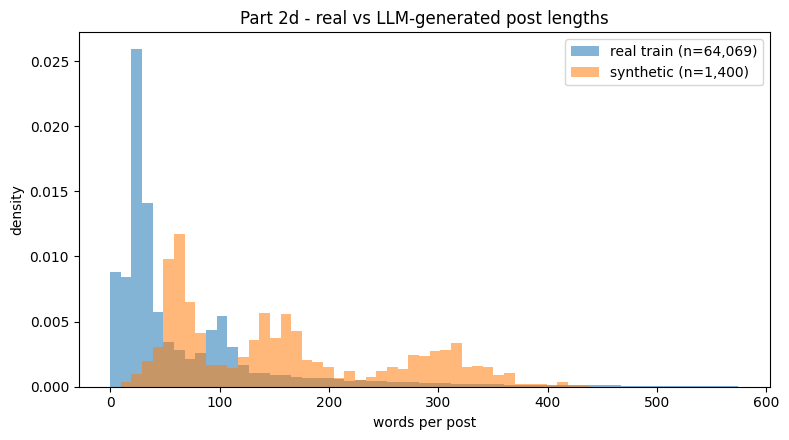

In [26]:
arm_specs = ((RUN_2D_NAMES['B'], 50), (RUN_2D_NAMES['C'], N_SYNTH_PER_CLASS),
             (RUN_2D_NAMES['D'], N_SYNTH_PER_CLASS))
expected = {n: RAW_PRED_DIR / f'{n}_seed{CANONICAL_SEED}.csv' for n, _ in arm_specs}
missing = [p.name for p in expected.values() if not p.exists()]

if not SYNTH_MANIFEST.exists():
    print('Synthetic set not generated yet - run the 2d cycle on Colab first.')
elif missing:
    print('Raw prediction CSVs still missing:')
    for name in missing:
        print(f'  - {name}')
    print('Train arms B-D on Colab, let Drive sync, then re-run this cell.')
else:
    man = json.loads(SYNTH_MANIFEST.read_text())
    for run_name, n_pc in arm_specs:
        path = expected[run_name]
        sidecar = path.with_suffix('.json')
        run = json.loads(sidecar.read_text()) if sidecar.exists() else None

        if run is None:
            print(f'WARNING: {sidecar.name} missing - no sanity/version record for {run_name}.')
        else:
            if not run['final_loss'] < MAX_FINAL_TRAIN_LOSS:
                print(f"WARNING: {run_name} final train loss {run['final_loss']} >= "
                      f'{MAX_FINAL_TRAIN_LOSS} - likely a silent failure.')
            if run['val_class_spread'] < len(classes):
                print(f"WARNING: {run_name} predicted only {run['val_class_spread']}/{len(classes)} "
                      'classes on val sanity sample - possible class collapse.')

        preds = pd.read_csv(path, index_col='test_id')
        assert preds.index.equals(test_df.index), f'{path.name} is not aligned with the frozen test index.'
        print(f'{run_name} scored.\n')


    # Figure 2: Real vs synthetic length distributions
    synth = load_synthetic()
    real_w = splits['train']['text'].str.split().str.len()
    synth_w = synth['text'].str.split().str.len()
    plot_part2_synth_length_hist(real_w, synth_w, fig_dir=FIG_DIR)

Arm B (32 + 50/class) reaches **73.85%** accuracy with suicidal recall 0.463 (the share of suicidal posts it catches). Arm C (32 + 200/class) reaches **73.22%** with suicidal recall 0.447. Both are well above the 32-only baseline. Arm D, synthetic-only at 200/class, reaches **64.32%** with suicidal recall 0.259. So the 32 real anchor posts are worth roughly 9 points of accuracy. Every 2d BERT arm still falls below the 74.51% mined-lexicon floor from Part 1.

## 2e. Apply the most effective technique(s)

Pick the winner by validation suicidal recall, subject to validation accuracy staying within 0.01 of the base mix; freeze one winner and touch the test set once, as `part2_best_combo`. Every candidate builds on the best mix so far (32 real plus 50/class synthetic). The candidates: (1) a suicidal-class boost (base mix plus fresh QC'd suicidal synthetic, written to `data/synthetic_2e/`); (2) distillation from the frozen 2c Gemma teacher (label a slice of the in-bounds 64k pool, class-balanced with a suicidal floor, plus the 32 real); (3) MentalBERT (`mental/mental-bert-base-uncased`), a bonus arm that runs only if the HF gate clears. Distillation labels training data only, so nothing leaks. Plan: section 4e.

2e settings. Decide on validation suicidal recall, accepting a candidate only if validation accuracy stays within `GUARDRAIL_ACC_DROP` (0.01) of the base mix; the frozen winner slug is `part2_best_combo`. Distillation labels the pool by a repeat-and-agree vote (`DISTILL_VOTES_MAX` 5 asks, keep when at least `DISTILL_VOTES_WIN` 3 agree). The suicidal boost writes to `data/synthetic_2e/`, distress and passive ideation only.

In [27]:
# 2e config (plan 4e). Rationale and decision rule are in the intro markdown above.
RUN_2E_NAME    = 'part2_best_combo'              # the frozen winner's ladder slug (the test deliverable)
RUN_2E_BASE    = 'part2_2e_base_llmgen50'        # guardrail reference: the 32 + llmgen 50/class mix
RUN_2E_BOOST   = 'part2_2e_suicidal_boost'       # Run 1
RUN_2E_DISTILL = 'part2_2e_distill_from_2c'      # Run 2 (headline)
RUN_2E_MBERT   = 'part2_2e_mentalbert'           # Run 3 (bonus)
MENTALBERT_MODEL = 'mental/mental-bert-base-uncased'   # gated, cc-by-nc-4.0: accept on HF + HF_TOKEN; cite

# Run 1 — fresh suicidal generation, written to data/synthetic_2e/ so the 2d set stays FROZEN.
SYNTH2E_DIR     = PROJECT_ROOT / 'data' / 'synthetic_2e'
BOOST_RAW_JSONL = LLM_DIR / 'part2e_suicidal_gen_raw.jsonl'
BOOST_PARQUET   = SYNTH2E_DIR / 'suicidal_boost.parquet'
BOOST_MANIFEST  = SYNTH2E_DIR / 'suicidal_boost_manifest.json'
N_BOOST_SUICIDAL = 150                            # extra QC-passed suicidal posts to add to the base mix

# Run 2 — distillation: label a random slice of the in-bounds 64k TRAIN pool (NEVER val/test)
# with the FROZEN 2c Gemma teacher, then class-balance (cap per teacher class; suicidal floored).
DISTILL_RAW_JSONL = LLM_DIR / 'part2e_distill_pseudolabels.jsonl'
N_DISTILL_POOL = 5000                             # pool slice to teacher-label (compute is free; ~35 min A100)
DISTILL_CAP    = 400                              # cap per teacher-predicted class; suicidal takes ALL (floor)

GUARDRAIL_ACC_DROP = 0.01                         # winner's val accuracy must be >= base val acc - this
DISTILL_VOTES_MAX = 5
DISTILL_VOTES_WIN = 3
DISTILL_TEMPERATURE = 0.7
DISTILL_TEACHER_MIN_VALACC = 0.60   # gate on teacher val accuracy (2c clears at 0.689)
DISTILL_POOL_IDS = LLM_DIR / 'part2e_distill_pool_ids.json'   # frozen pool slice (disjoint from val/test)
DISTILL_PARQUET  = SYNTH2E_DIR / 'distill_mix.parquet'        # 32 gold + gated pseudo-labels (trained on)
DISTILL_MANIFEST = SYNTH2E_DIR / 'distill_manifest.json'

# --- 2e suicidal-boost generation (plan section 4e Run 1) ---
BOOST_IDX_OFFSET = 10_000   # offset gen indices so boost prompts differ from the 2d suicidal set
BOOST_RAW_QUOTA  = 450      # raw suicidal posts to generate (buffer for ~150 QC-passed); raise + re-run if short

# --- 2e decision handoff: local cell writes the winner, the Colab driver reads it for the test run ---
DECISION_2E_PATH = LLM_DIR / 'part2e_decision.json'

print(f'2e config ready — base = {RUN_2E_BASE}; decide on val suicidal recall, '
      f'accuracy guardrail within {GUARDRAIL_ACC_DROP:.0%} of base. Winner -> {RUN_2E_NAME} (test once).')


2e config ready — base = part2_2e_base_llmgen50; decide on val suicidal recall, accuracy guardrail within 1% of base. Winner -> part2_best_combo (test once).


`train_2e` reuses the 2a recipe and canonical seed but takes the encoder as an argument, so MentalBERT slots in unchanged. It predicts a chosen split and stages predictions; candidates predict validation, and only the frozen winner predicts test, once.

In [28]:
def train_2e(train_df, run_name, eval_df, eval_tag, model_name=None):
    """2a recipe parameterized by encoder: train on Colab, stage eval_df predictions.

    Thin adapter to src.models.trainer.train_2e (lazy import); model_name defaults to the
    2a encoder (cfg.model_name)."""
    if not RUN_TRAINING:
        print(f'{run_name}: RUN_TRAINING is False — train on Colab. Skipping.')
        return None
    from src.models.trainer import train_2e as _impl
    return _impl(
        train_df, run_name, eval_df, eval_tag, cfg=cfg, classes=classes, id2label=id2label,
        label2id=label2id, run_training=RUN_TRAINING, model_name=model_name,
    )


Build the first candidate's suicidal-class boost: fresh suicidal-only synthetic posts (distress and passive ideation only), QC'd by embedding dedup against the 32 seeds and the frozen 2d suicidal set, then judged by the frozen 2c Gemma. The generation indices are shifted from the 2d set; frozen to `data/synthetic_2e/`, resumable.

In [29]:
# 2e Run 1: suicidal-class boost (generate, QC, freeze to data/synthetic_2e/).
if BOOST_MANIFEST.exists():
    print(f'{BOOST_PARQUET.name} is FROZEN (manifest exists) - suicidal boost already built.')
    print(json.dumps(json.loads(BOOST_MANIFEST.read_text())['counts'], indent=2))
elif not _gpu_available():
    print('No CUDA GPU - run this cell on Colab (A100). Skipping.')
else:
    import torch
    from tqdm.auto import tqdm
    from transformers import AutoModel, AutoTokenizer

    CLS = 'suicidal'
    # --- generation: resumable, append every raw to BOOST_RAW_JSONL, top up to BOOST_RAW_QUOTA ---
    rows = []
    if BOOST_RAW_JSONL.exists():
        with BOOST_RAW_JSONL.open() as f:
            rows = [json.loads(l) for l in f if l.strip()]
    have = [r['idx'] for r in rows if r['text']]
    next_idx = max((r['idx'] for r in rows), default=BOOST_IDX_OFFSET - 1) + 1
    need = max(0, BOOST_RAW_QUOTA - len(have))
    print(f'Raw suicidal parsed so far: {len(have)}; generating {need} more (quota {BOOST_RAW_QUOTA}).')
    with BOOST_RAW_JSONL.open('a') as f:
        bar = tqdm(total=need, desc='gen suicidal', unit='post')
        while need > 0:
            idxs = list(range(next_idx, next_idx + min(GEN_BATCH, need + 4)))
            built = [build_gen_messages(CLS, i) for i in idxs]
            raws = generate_posts([b[0] for b in built], idxs[0])
            for i, (attrs, raw) in zip(idxs, zip([b[1] for b in built], raws)):
                text = parse_post(raw)
                f.write(json.dumps({'gen_id': f'suicidal_boost_{i:05d}', 'cls': CLS, 'idx': i,
                                    'attrs': attrs, 'text': text,
                                    'raw': None if text else raw[:500]}) + '\n')
                if text and need > 0:
                    bar.update(1)
                    need -= 1
            f.flush()
            next_idx = idxs[-1] + 1
        bar.close()

    with BOOST_RAW_JSONL.open() as f:
        raw_rows = [json.loads(l) for l in f if l.strip()]
    cand = pd.DataFrame([r for r in raw_rows if r['text']]).sort_values('idx').reset_index(drop=True)
    print(f'{len(cand)} parsed suicidal candidates.')

    # --- QC stage 1: embedding dedup vs the 32 seeds AND the frozen 2d suicidal set, keep-first ---
    emb_tok = AutoTokenizer.from_pretrained(EMB_MODEL)
    emb_model = AutoModel.from_pretrained(EMB_MODEL).to('cuda').eval()
    def embed(texts):
        out = []
        for s in tqdm(range(0, len(texts), 256), desc='embed', unit='batch'):
            enc = emb_tok(texts[s:s + 256], padding=True, truncation=True, max_length=256,
                          return_tensors='pt').to('cuda')
            with torch.no_grad():
                h = emb_model(**enc).last_hidden_state
            mask = enc['attention_mask'].unsqueeze(-1)
            v = (h * mask).sum(1) / mask.sum(1)
            out.append(torch.nn.functional.normalize(v, dim=1).cpu())
        return torch.cat(out).numpy()

    ref_texts = train32['text'].tolist()
    if SYNTH_MANIFEST.exists():
        prior = load_synthetic()
        ref_texts += prior.loc[prior['status'] == CLS, 'text'].tolist()
    E = embed(cand['text'].tolist() + ref_texts)
    cand_E, ref_E = E[:len(cand)], E[len(cand):]
    keep, kept_vecs = [], [ref_E]
    for v in cand_E:
        ok = bool((np.concatenate(kept_vecs) @ v).max() < DEDUP_COSINE)
        keep.append(ok)
        if ok:
            kept_vecs.append(v[None, :])
    cand['dedup_kept'] = keep
    dedup = cand[cand['dedup_kept']].reset_index(drop=True)
    print(f'Dedup: kept {len(dedup)}/{len(cand)} (cosine < {DEDUP_COSINE}, vs seeds + 2d suicidal).')

    # --- QC stage 2: judge must agree it is suicidal (frozen 2c Gemma) ---
    judged = []
    for s in tqdm(range(0, len(dedup), BATCH_2C), desc='judge', unit='batch'):
        judged.extend(judge_batch(dedup['text'].iloc[s:s + BATCH_2C].tolist()))
    dedup['judge_label'] = [j['label'] for j in judged]
    dedup['judge_conf'] = [j['conf'] for j in judged]
    accepted = dedup[dedup['judge_label'] == CLS].reset_index(drop=True)
    print(f'Judge agreement: kept {len(accepted)}/{len(dedup)} as suicidal.')

    # --- freeze, or report a shortfall (raise BOOST_RAW_QUOTA and re-run) ---
    if len(accepted) < N_BOOST_SUICIDAL:
        print(f'SHORTFALL: {len(accepted)} < {N_BOOST_SUICIDAL} QC-passed. NOT persisting. '
              f'Raise BOOST_RAW_QUOTA (now {BOOST_RAW_QUOTA}) in the config cell and re-run this cell.')
    else:
        final = (accepted.head(N_BOOST_SUICIDAL).rename(columns={'cls': 'status'})
                 [['gen_id', 'text', 'status', 'judge_conf']].reset_index(drop=True))
        SYNTH2E_DIR.mkdir(parents=True, exist_ok=True)
        final.to_parquet(BOOST_PARQUET, index=False)
        fp = hashlib.sha256('\n'.join(f'{r.gen_id}|{r.status}|{r.text}'
                                      for r in final.itertuples()).encode()).hexdigest()
        BOOST_MANIFEST.write_text(json.dumps({
            'content_sha256': fp, 'n': int(len(final)), 'class': CLS,
            'generator': MODEL_2D_GEN, 'judge': MODEL_2D_JUDGE,
            'prompt_version': GEN_PROMPT_VERSION, 'idx_offset': BOOST_IDX_OFFSET,
            'dedup_cosine': DEDUP_COSINE, 'raw_quota': BOOST_RAW_QUOTA,
            'counts': {'raw_parsed': int(len(cand)), 'dedup_kept': int(len(dedup)),
                       'judge_agree': int(len(accepted)), 'kept': int(len(final))}}, indent=2))
        print(f'FROZEN: {BOOST_PARQUET.name} ({len(final)} suicidal rows, fp {fp[:12]}...) + manifest.')

suicidal_boost.parquet is FROZEN (manifest exists) - suicidal boost already built.
{
  "raw_parsed": 451,
  "dedup_kept": 451,
  "judge_agree": 275,
  "kept": 150
}


The quality-check stages report the raw parsed candidates, the count kept after dedup, and the count the judge agreed were suicidal. Here 451 candidates parsed, all 451 survived dedup, the judge agreed 275 were suicidal, and we froze the target 150 (`N_BOOST_SUICIDAL`). A shortfall would have saved nothing.

Build the headline distillation candidate. Draw a slice of the in-bounds 64k pool (never validation or test) and label it by self-consistency vote (5 asks, keep when at least 3 agree). Cap each predicted class at `DISTILL_CAP` (400), keep all suicidal, and add the 32 gold examples. A teacher gate requires the 2c validation accuracy to clear `DISTILL_TEACHER_MIN_VALACC` (0.60); 2c clears at 68.9%.

In [30]:
# 2e Run 2 (headline): distillation from the frozen 2c teacher.
if DISTILL_MANIFEST.exists():
    print(f'{DISTILL_PARQUET.name} is FROZEN (manifest exists) - distillation set already built.')
    print(json.dumps(json.loads(DISTILL_MANIFEST.read_text())['counts'], indent=2))
elif not _gpu_available():
    print('No CUDA GPU - run this cell on Colab (A100). Skipping.')
elif FROZEN_CAND is None:
    print('No frozen 2c teacher prompt yet - run 2c prompt development first (plan 4c). Skipping.')
else:
    import torch
    from tqdm.auto import tqdm

    # teacher-quality gate (plan 4e): the frozen 2c candidate's VALIDATION dev accuracy
    teacher_valacc = None
    if PROMPTDEV_CANDS_PATH.exists():
        scored = json.loads(PROMPTDEV_CANDS_PATH.read_text())['candidates']
        match = [s for s in scored if s['name'] == FROZEN_CAND['name']]
        teacher_valacc = match[0]['dev_accuracy'] if match else None
    assert teacher_valacc is not None and teacher_valacc >= DISTILL_TEACHER_MIN_VALACC, (
        f'teacher val accuracy {teacher_valacc} below the gate {DISTILL_TEACHER_MIN_VALACC} - '
        'a weak teacher just injects confirmation-bias noise; do not distill.')
    print(f'Teacher gate OK: {FROZEN_CAND["name"]} val acc {teacher_valacc:.3f} >= {DISTILL_TEACHER_MIN_VALACC}.')

    # --- frozen pool slice: from train, EXCLUDING the 32 gold, never val/test ---
    if DISTILL_POOL_IDS.exists():
        pool_ids = json.loads(DISTILL_POOL_IDS.read_text())['ids']
        pool = splits['train'].loc[pool_ids]
    else:
        eligible = splits['train'].drop(index=train32.index, errors='ignore')
        pool = eligible.sample(n=min(N_DISTILL_POOL, len(eligible)), random_state=SEED)
        DISTILL_POOL_IDS.write_text(json.dumps({'ids': [int(i) for i in pool.index],
                                                'n': int(len(pool)), 'seed': SEED}, indent=2))
    assert pool.index.intersection(test_df.index).empty, 'pool slice overlaps TEST - abort'
    assert pool.index.intersection(splits['val'].index).empty, 'pool slice overlaps VAL - abort'
    print(f'Pool slice: {len(pool)} train rows (disjoint from the 32 gold, val and test).')

    # --- self-consistency teacher labeling (sampled), resumable to DISTILL_RAW_JSONL ---
    done = {}
    if DISTILL_RAW_JSONL.exists():
        with DISTILL_RAW_JSONL.open() as f:
            for l in f:
                if l.strip():
                    r = json.loads(l)
                    done[int(r['row_id'])] = r
    teacher = get_model()   # frozen 2c Gemma (same instance as 2c / the 2d judge)

    def classify_sampled(texts):
        """One SAMPLED teacher batch (T=DISTILL_TEMPERATURE) -> list of parsed labels/None."""
        model, proc = teacher
        convs = [[{'role': 'system', 'content': [{'type': 'text', 'text': FROZEN_CAND['system_prompt']}]},
                  {'role': 'user', 'content': [{'type': 'text', 'text': t[:MAX_INPUT_CHARS]}]}]
                 for t in texts]
        enc = proc.apply_chat_template(convs, add_generation_prompt=True, tokenize=True,
                                       return_dict=True, return_tensors='pt', padding=True).to(model.device)
        with torch.no_grad():
            out = model.generate(**enc, max_new_tokens=FROZEN_CAND['max_new_tokens'],
                                 do_sample=True, temperature=DISTILL_TEMPERATURE, top_p=0.95)
        raws = proc.batch_decode(out[:, enc['input_ids'].shape[1]:], skip_special_tokens=True)
        return [_parse_label(r) for r in raws]

    todo = [(int(i), t) for i, t in zip(pool.index, pool['text']) if int(i) not in done]
    if todo:
        with DISTILL_RAW_JSONL.open('a') as f:
            for s in tqdm(range(0, len(todo), BATCH_2C), desc='teacher votes', unit='batch'):
                chunk = todo[s:s + BATCH_2C]
                texts = [t[:MAX_INPUT_CHARS] for _, t in chunk]
                votes = [[] for _ in chunk]
                for _ in range(DISTILL_VOTES_MAX):
                    for k, lab in enumerate(classify_sampled(texts)):
                        votes[k].append(lab)
                for (rid, _), vs in zip(chunk, votes):
                    counts = {}
                    for lab in vs:
                        if lab is not None:
                            counts[lab] = counts.get(lab, 0) + 1
                    top = max(counts, key=counts.get) if counts else None
                    label = top if (top is not None and counts[top] >= DISTILL_VOTES_WIN) else None
                    rec = {'row_id': rid, 'votes': vs, 'label': label}
                    f.write(json.dumps(rec) + '\n')
                    done[rid] = rec
                f.flush()

    # --- gate: keep converged labels, cap per class, suicidal floored ---
    labeled = [(rid, done[rid]['label']) for rid in (int(i) for i in pool.index)
               if done[rid]['label'] is not None]
    n_converged = len(labeled)
    by_class = {}
    for rid, lab in labeled:
        by_class.setdefault(lab, []).append(rid)
    kept_ids = []
    for lab, ids in by_class.items():
        kept_ids += ids if lab == 'suicidal' else ids[:DISTILL_CAP]
    pseudo = pool.loc[kept_ids].copy()
    pseudo['status'] = [done[int(i)]['label'] for i in pseudo.index]
    mix = pd.concat([train32[['text', 'status']], pseudo[['text', 'status']]], ignore_index=True)
    print(f'Converged {n_converged}/{len(pool)} (>= {DISTILL_VOTES_WIN}/{DISTILL_VOTES_MAX} agree); '
          f'after cap/floor kept {len(pseudo)} pseudo + 32 gold = {len(mix)} rows.')
    print('Pseudo-label distribution:', {k: int((pseudo['status'] == k).sum()) for k in classes})

    # --- freeze ---
    SYNTH2E_DIR.mkdir(parents=True, exist_ok=True)
    mix.to_parquet(DISTILL_PARQUET, index=False)
    fp = hashlib.sha256('\n'.join(f'{r.status}|{r.text}' for r in mix.itertuples()).encode()).hexdigest()
    DISTILL_MANIFEST.write_text(json.dumps({
        'content_sha256': fp, 'n': int(len(mix)), 'n_gold': int(len(train32)),
        'n_pseudo': int(len(pseudo)), 'n_pool': int(len(pool)), 'n_converged': int(n_converged),
        'teacher': {'model': MODEL_2C, 'candidate': FROZEN_CAND['name'], 'hash': FROZEN_CAND['hash'],
                    'val_accuracy': teacher_valacc},
        'self_consistency': {'votes_max': DISTILL_VOTES_MAX, 'votes_win': DISTILL_VOTES_WIN,
                             'temperature': DISTILL_TEMPERATURE},
        'cap_per_class': DISTILL_CAP, 'suicidal_floored': True,
        'counts': {k: int((pseudo['status'] == k).sum()) for k in classes}}, indent=2))
    print(f'FROZEN: {DISTILL_PARQUET.name} ({len(mix)} rows, fp {fp[:12]}...) + manifest.')

distill_mix.parquet is FROZEN (manifest exists) - distillation set already built.
{
  "anxiety": 400,
  "bipolar": 400,
  "depression": 400,
  "normal": 400,
  "personality disorder": 400,
  "stress": 400,
  "suicidal": 630
}


The frozen 2c teacher clears its gate at validation accuracy 68.9%, above the 0.60 threshold. We label a 5,000-row in-bounds training slice that does not overlap the 32 gold examples, validation, or test. 4,861 of the 5,000 rows reach a clear label under the keep-if-at-least-three-of-five-votes-agree rule.

After the 400-per-class cap, with the suicidal class kept in full, the frozen mix is 3,030 labeled-by-the-teacher rows plus the 32 gold rows (3,062 total), 400 per class and 630 suicidal.

Run the 2e arms: each trains on its mix and predicts validation (the decision split); already-staged arms are skipped, and MentalBERT runs only if its gate clears. After the local decision names the winner, the winner trains once on test as `part2_best_combo`.

In [31]:
# 2e arms driver: train each candidate, predict validation, then the winner on test once.
if not RUN_TRAINING:
    print('RUN_TRAINING is False - 2e arms train on Colab (plan section 6).')
elif not SYNTH_MANIFEST.exists():
    print('Base mix needs the frozen 2d synthetic set - run the 2d cycle first. Skipping.')
else:
    synth = load_synthetic()
    per50 = synth.groupby('status', group_keys=False).head(50)
    base_mix = pd.concat([train32[['text', 'status']], per50[['text', 'status']]], ignore_index=True)

    candidates = [(RUN_2E_BASE, base_mix, MODEL_NAME)]
    if BOOST_MANIFEST.exists():
        boost = pd.read_parquet(BOOST_PARQUET)
        candidates.append((RUN_2E_BOOST,
                           pd.concat([base_mix, boost[['text', 'status']]], ignore_index=True), MODEL_NAME))
    else:
        print(f'{RUN_2E_BOOST}: no frozen suicidal boost yet (run the boost cell) - skipping.')
    if DISTILL_MANIFEST.exists():
        candidates.append((RUN_2E_DISTILL,
                           pd.read_parquet(DISTILL_PARQUET)[['text', 'status']], MODEL_NAME))
    else:
        print(f'{RUN_2E_DISTILL}: no frozen distillation set yet (run the distill cell) - skipping.')
    # MentalBERT: only if the gated encoder actually loads (accept the HF gate to include it)
    try:
        AutoTokenizer.from_pretrained(MENTALBERT_MODEL)
        candidates.append((RUN_2E_MBERT, base_mix, MENTALBERT_MODEL))
    except Exception as e:
        print(f'{RUN_2E_MBERT}: MentalBERT weights did not load ({type(e).__name__}) - accept the '
              'HF gate to include it; skipping (it stays a proposed improvement).')

    val_eval = splits['val'][['text', 'status']]
    for run_name, frame, encoder in candidates:
        if (RAW_PRED_DIR / f'{run_name}_val.csv').exists():
            print(f'{run_name}: val predictions already staged - skipping retrain.')
            continue
        print(f'{run_name}: {len(frame)} train rows, encoder {encoder}')
        train_2e(frame, run_name, val_eval, 'val', model_name=encoder)

    # winner -> test (single touch): the local decision cell writes DECISION_2E_PATH
    frame_by_name = {n: (f, enc) for n, f, enc in candidates}
    test_csv = RAW_PRED_DIR / f'{RUN_2E_NAME}_test.csv'
    if not DECISION_2E_PATH.exists():
        print('No decision file yet - run the local decision cell, then re-run this cell for the winner test run.')
    elif test_csv.exists():
        print(f'{test_csv.name} already staged - winner test run done.')
    else:
        winner = json.loads(DECISION_2E_PATH.read_text())['winner']
        if winner in frame_by_name:
            f, enc = frame_by_name[winner]
            print(f'Winner {winner} -> predicting TEST once as {RUN_2E_NAME}.')
            train_2e(f, RUN_2E_NAME, test_df, 'test', model_name=enc)
        else:
            print(f'Decision names {winner}, but its frame is not available here - check the arm ran.')

part2_2e_base_llmgen50: val predictions already staged - skipping retrain.
part2_2e_suicidal_boost: val predictions already staged - skipping retrain.
part2_2e_distill_from_2c: val predictions already staged - skipping retrain.
part2_2e_mentalbert: val predictions already staged - skipping retrain.
part2_best_combo_test.csv already staged - winner test run done.


Decide locally: score each candidate on validation (not added to the main table), then apply the pre-set rule, the highest validation suicidal recall whose validation accuracy is within 0.01 of base. Name the winner, stage its test run, and score it once through `evaluate_model`.

In [32]:
# 2e decision (local): score candidates on validation, apply the rule, score the winner on test once.
val_gold = splits['val']['status']
specs = [('base', RUN_2E_BASE), ('boost', RUN_2E_BOOST),
         ('distill', RUN_2E_DISTILL), ('mentalbert', RUN_2E_MBERT)]
table, val_metrics = [], {}
for tag, run_name in specs:
    path = RAW_PRED_DIR / f'{run_name}_val.csv'
    if not path.exists():
        continue
    preds = pd.read_csv(path, index_col='row_id')
    assert preds.index.equals(splits['val'].index), (
        f'{path.name} not aligned with the validation index - regenerate on Colab.')
    m = evaluate_predictions(val_gold.to_numpy(), preds['y_pred'].to_numpy(), list(classes))
    val_metrics[run_name] = m
    table.append({'candidate': tag, 'run_name': run_name, 'val_acc': m['accuracy'],
                  'val_suicidal_recall': m['per_class']['suicidal']['recall'],
                  'val_macro_f1': m['macro_f1']})
if not table:
    print('No staged validation predictions yet - train the 2e arms on Colab first.')
else:
    print('2e candidates on VALIDATION (off-ladder):')
    print(pd.DataFrame(table).to_string(index=False))
    if RUN_2E_BASE not in val_metrics:
        print('\nBase mix not scored yet - cannot apply the accuracy guardrail. Train the base arm.')
    else:
        base_acc = val_metrics[RUN_2E_BASE]['accuracy']
        floor = base_acc - GUARDRAIL_ACC_DROP
        tab = pd.DataFrame(table)
        contenders = tab[(tab['run_name'] != RUN_2E_BASE) & (tab['val_acc'] >= floor)]
        print(f'\nGuardrail: val acc >= {floor:.4f} (base {base_acc:.4f} - {GUARDRAIL_ACC_DROP:.0%}).')
        if contenders.empty:
            print('No candidate clears the accuracy guardrail - base mix stays the choice.')
        else:
            win = contenders.sort_values('val_suicidal_recall', ascending=False).iloc[0]
            print(f"WINNER: {win['run_name']} ({win['candidate']}) - val suicidal recall "
                  f"{win['val_suicidal_recall']:.3f}, val acc {win['val_acc']:.4f}.")
            DECISION_2E_PATH.write_text(json.dumps(
                {'winner': win['run_name'], 'candidate': win['candidate'],
                 'decided_on': 'validation', 'metric': 'suicidal_recall',
                 'guardrail_acc_floor': float(floor),
                 'val_metrics': {k: {'accuracy': v['accuracy'],
                                     'suicidal_recall': v['per_class']['suicidal']['recall']}
                                 for k, v in val_metrics.items()}}, indent=2))
            print(f'Wrote {DECISION_2E_PATH.name} - now re-run the arms driver on Colab to predict '
                  'TEST with the winner, then re-run this cell to score it.')

    # test-once scoring: only after the winner's test CSV is staged
    test_csv = RAW_PRED_DIR / f'{RUN_2E_NAME}_test.csv'
    metrics_json = METRICS_DIR / f'{RUN_2E_NAME}.json'
    if metrics_json.exists():
        print(f'\n{RUN_2E_NAME}.json already exists - test already scored once. Not re-touching test.')
    elif test_csv.exists():
        preds = pd.read_csv(test_csv, index_col='row_id')
        assert preds.index.equals(test_df.index), (
            f'{test_csv.name} not aligned with the frozen test index - regenerate on Colab.')
        dec = json.loads(DECISION_2E_PATH.read_text()) if DECISION_2E_PATH.exists() else {}
        print(f'\nScored {RUN_2E_NAME} on TEST (single touch). Re-run notebook 00 to refresh the ladder.')

2e candidates on VALIDATION (off-ladder):
 candidate                 run_name  val_acc  val_suicidal_recall  val_macro_f1
      base   part2_2e_base_llmgen50 0.743976             0.447135      0.734490
     boost  part2_2e_suicidal_boost 0.734424             0.481985      0.728017
   distill part2_2e_distill_from_2c 0.765451             0.705848      0.764672
mentalbert      part2_2e_mentalbert 0.752466             0.448907      0.735505

Guardrail: val acc >= 0.7340 (base 0.7440 - 1%).
WINNER: part2_2e_distill_from_2c (distill) - val suicidal recall 0.706, val acc 0.7655.
Wrote part2e_decision.json - now re-run the arms driver on Colab to predict TEST with the winner, then re-run this cell to score it.

part2_best_combo.json already exists - test already scored once. Not re-touching test.


Distillation wins. On test it reaches **75.70% accuracy** with a suicidal recall of **74.5%**, the ethics-critical number we track through Parts 2 to 4. That recall is far above the 45.3% of the Part 1 mined lexicon and the 16.3% of the single-arm 2a BERT. The accuracy also clears the 74.51% lexicon floor.

## Bias Audit: Group-Mention Sensitivity

We test whether predictions depend on the gender of people mentioned in a post (group-mention sensitivity, not the author's demographic). The slicing audit computes accuracy and suicidal recall per gendered slice (female, male, both, neither) from the saved predictions; the counterfactual probe swaps gendered terms in validation posts and measures how often the prediction flips, especially into or out of suicidal. Swapping is imperfect in English, and small slices get a 95% confidence interval.

/tmp/ipykernel_62702/313879848.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  fem = test_df['text'].str.contains(FEM_RE, case=False, regex=True)
/tmp/ipykernel_62702/313879848.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mal = test_df['text'].str.contains(MAL_RE, case=False, regex=True)


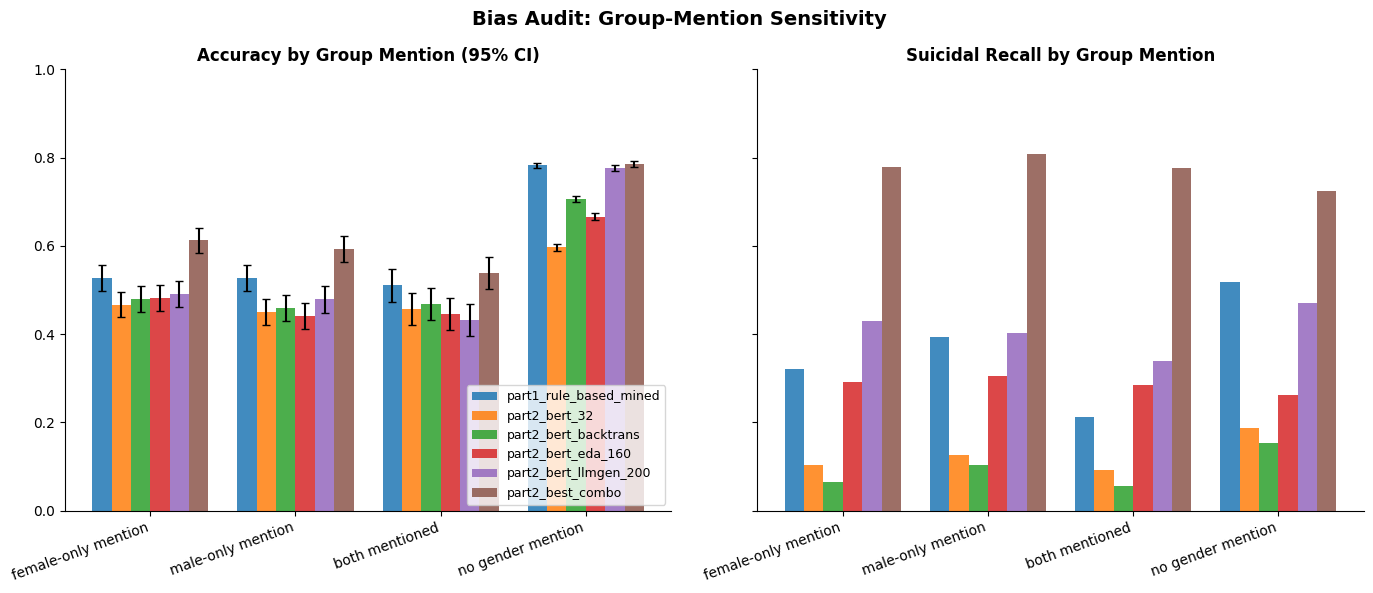

In [33]:
FEM_RE = r"\b(she|her|hers|herself|girlfriend|gf|wife|mom|mother|sister|daughter|aunt|grandma|woman|girl)\b"
MAL_RE = r"\b(he|him|his|himself|boyfriend|bf|husband|dad|father|brother|son|uncle|grandpa|man|boy)\b"

fem = test_df['text'].str.contains(FEM_RE, case=False, regex=True)
mal = test_df['text'].str.contains(MAL_RE, case=False, regex=True)
slices = {
    'female-only mention': fem & ~mal,
    'male-only mention': mal & ~fem,
    'both mentioned': fem & mal,
    'no gender mention': ~fem & ~mal
}

PREFERRED = ['part1_rule_based_mined', RUN_2A_NAME, RUN_2B_BT_NAME, RUN_2B_EDA_NAME, RUN_2D_NAMES['C'], 'part2_best_combo']
avail = [n for n in PREFERRED if (PRED_DIR / f'{n}.csv').exists()]

rows = []
for name in avail:
    y_pred = load_predictions(name)['y_pred']
    for sl, mask in slices.items():
        yt, yp = y_test[mask.to_numpy()], y_pred[mask].to_numpy()
        n = int(mask.sum())
        acc = float((yt == yp).mean())
        half = 1.96 * np.sqrt(acc * (1 - acc) / n)
        sui = yt == 'suicidal'
        rec = float((yp[sui] == 'suicidal').mean()) if sui.sum() else np.nan
        rows.append({
            'model': name, 'slice': sl, 'n': n,
            'accuracy': acc, 'acc_95half': half,
            'n_suicidal': int(sui.sum()), 'suicidal_recall': rec
        })
audit = pd.DataFrame(rows)

plot_part2_bias_audit(audit, avail, slices, fig_dir=FIG_DIR)


The four slices are female-only mention (1,115 posts), male-only mention (1,059), both (723), and no gender mention (17,125). All five audited models, the mined lexicon and the four Part 2 BERT arms, show an across-slice accuracy spread above their joint 95% noise band (0.15 to 0.35). This is driven by the large no-gender-mention slice being easier, and suicidal recall is lower on the gendered slices. These flags measure group-mention sensitivity, not author demographics. They feed a writeup caveat, not a model change.

In [34]:
# Validation gender-swap probe
CKPT_2A = RAW_PRED_DIR / f'{RUN_2A_NAME}_seed{CANONICAL_SEED}_model'
if not CKPT_2A.exists():
    print(f'{CKPT_2A.name} not found. Sync checkpoint from Drive.')
else:
    import torch
    from transformers import AutoModelForSequenceClassification, AutoTokenizer

    PAIRS = [('he', 'she'), ('him', 'her'), ('his', 'her'), ('himself', 'herself'),
             ('boyfriend', 'girlfriend'), ('bf', 'gf'), ('husband', 'wife'),
             ('brother', 'sister'), ('father', 'mother'), ('dad', 'mom'),
             ('son', 'daughter'), ('uncle', 'aunt'), ('man', 'woman'), ('boy', 'girl')]

    SWAP = {**{a: b for a, b in PAIRS}, **{b: a for a, b in PAIRS}}
    SWAP_RE = re.compile(rf"\b({'|'.join(sorted(SWAP, key=len, reverse=True))})\b", re.IGNORECASE)

    def gender_swap(text):
        return SWAP_RE.sub(lambda m: SWAP[m.group(0).lower()].capitalize() if m.group(0)[0].isupper() else SWAP[m.group(0).lower()], text)

    val_df = splits['val']
    gendered = val_df[val_df['text'].str.contains(SWAP_RE, regex=True)]
    probe = gendered.sample(min(400, len(gendered)), random_state=SEED)
    swapped = probe['text'].map(gender_swap)

    tok = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(CKPT_2A).eval()
    id2lab = model.config.id2label

    def predict(texts, bs=64):
        out = []
        for s in range(0, len(texts), bs):
            enc = tok(texts[s:s + bs], truncation=True, max_length=MAX_LENGTH, padding=True, return_tensors='pt')
            with torch.no_grad():
                out.extend(id2lab[int(i)] for i in model(**enc).logits.argmax(-1))
        return np.array(out)

    p_orig, p_swap = predict(probe['text'].tolist()), predict(swapped.tolist())
    flips = p_orig != p_swap

    print(f"Probe: {len(probe)} posts. Flip rate: {flips.mean():.3f} ({flips.sum()}/{len(probe)})")
    print(f"Flips INTO suicidal: {((p_orig != 'suicidal') & (p_swap == 'suicidal')).sum()}")
    print(f"Flips OUT of suicidal: {((p_orig == 'suicidal') & (p_swap != 'suicidal')).sum()}")
    if flips.sum():
        print(pd.Series([f'{a} -> {b}' for a, b in zip(p_orig[flips], p_swap[flips])]).value_counts().to_string())


/tmp/ipykernel_62702/275263329.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  gendered = val_df[val_df['text'].str.contains(SWAP_RE, regex=True)]


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Probe: 400 posts. Flip rate: 0.020 (8/400)
Flips INTO suicidal: 2
Flips OUT of suicidal: 0
depression -> normal               3
bipolar -> suicidal                1
depression -> anxiety              1
personality disorder -> anxiety    1
bipolar -> depression              1
depression -> suicidal             1


The probe swaps gendered terms in the validation posts and measures how often the prediction flips, and whether flips into or out of `suicidal` are uneven. Validation-only; runs once the canonical 2a checkpoint syncs from Drive.

## Summary & Conclusion

Throughout this analysis, we explored multiple strategies to maximize classification performance when restricted to only 32 labeled examples:

1.  **Baseline (BERT on 32 seeds)**: Yielded relatively low overall accuracy (~57%) and, crucially, highly unstable suicidal recall due to having only 4 suicidal examples in the training set.
2.  **Dataset Augmentation**: Both Back-translation and EDA provided marginal improvements in accuracy but largely failed to meaningfully boost the ethics-critical suicidal recall.
3.  **Zero-shot LLM**: Using `gemma-3-4b-it` without any training achieved a strong 72.33% accuracy and a very high 67.6% suicidal recall, establishing it as a highly capable model out-of-the-box.
4.  **LLM-generated data**: Supplementing the 32 real seeds with synthetic posts generated by Llama improved the student BERT model's accuracy up to ~73%, showing that synthetic generation is viable but still trailed the Part 1 baseline.
5.  **Best Combination (Distillation)**: The winning approach was knowledge distillation. By having the strong zero-shot Gemma teacher label a 5,000-row pool of unlabeled data (using self-consistency voting), and training the BERT student on this pseudo-labeled mix alongside the 32 gold seeds, we achieved **75.70% accuracy** and **74.5% suicidal recall** on the test set.

**Conclusion:** When gold labels are extremely scarce, simply augmenting the few available examples is insufficient. Instead, leveraging a powerful open-weights LLM to accurately pseudo-label an unlabeled pool of data (Knowledge Distillation) is the most effective way to train a smaller, efficient student model that is both accurate and safe.